In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from scipy.ndimage import binary_fill_holes
from scipy.interpolate import interp1d
from sympy import symbols, solve
from openpiv import tools, pyprocess, validation, filters, scaling
import pathlib
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import cv2
import os
import alphashape
from shapely.geometry import Polygon, MultiPolygon
import math
mpl.rcParams['figure.dpi'] = 500

In [2]:
import cv2
import os

video_path = '/Volumes/PortableSSD/newrun/ClayDI.MOV'
output_dir = '/Volumes/PortableSSD/newrun/clayDI/images'
os.makedirs(output_dir, exist_ok=True)


# Video capture
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video file.")
    exit()

# Video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Define time range in seconds
start_time = 2 * 60  # 2 minutes
end_time = 8 * 60    # 5 minutes

# Calculate corresponding frame range
start_frame = int(start_time * fps)
end_frame = int(end_time * fps)

# Set the starting point in the video
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

frame_count = start_frame
while frame_count < end_frame:
    ret, frame = cap.read()
    if not ret:
        print(f"Frame {frame_count} could not be read. Exiting.")
        break

    # Save the frame as an image
    frame_filename = os.path.join(output_dir, f"frame_{frame_count}.png")
    cv2.imwrite(frame_filename, frame)

    frame_count += 1

print(f"Frames extracted and saved in '{output_dir}'.")
cap.release()

Frames extracted and saved in '/Volumes/PortableSSD/newrun/clayDI/images'.


In [3]:
import os
import cv2
import numpy as np

def compute_and_save_average_images(base_dir, start_frame, end_frame, step=800):
    for i in range(start_frame, end_frame, step):
        frame_range = range(i, i + step)
        image_paths = [os.path.join(base_dir, f"frame_{j}.png") for j in frame_range]
        sum_image = None
        num_images = len(frame_range)
        
        for image_path in image_paths:
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is not None:
                if sum_image is None:
                    sum_image = np.zeros_like(image, dtype=np.float32)
                sum_image += image.astype(np.float32)
            else:
                print(f"Image not found at {image_path}")
        
        if sum_image is not None:
            average_image = sum_image / num_images
            average_image = average_image.astype(np.uint8)
            average_image_path = os.path.join(base_dir, f"average_image{i}.png")
            cv2.imwrite(average_image_path, average_image)
            print(f"Saved average image for range {i}-{i + step} as {average_image_path}")
        else:
            print(f"No images found for range {i}-{i + step}")

if __name__ == "__main__":
    base_dir = '/Volumes/PortableSSD/newrun/clayDI/images'


    start_frame = 3480
    end_frame = 13919
    compute_and_save_average_images(base_dir, start_frame, end_frame)

Saved average image for range 3480-4280 as /Volumes/PortableSSD/newrun/clayDI/images/average_image3480.png
Saved average image for range 4280-5080 as /Volumes/PortableSSD/newrun/clayDI/images/average_image4280.png
Saved average image for range 5080-5880 as /Volumes/PortableSSD/newrun/clayDI/images/average_image5080.png
Saved average image for range 5880-6680 as /Volumes/PortableSSD/newrun/clayDI/images/average_image5880.png
Saved average image for range 6680-7480 as /Volumes/PortableSSD/newrun/clayDI/images/average_image6680.png
Saved average image for range 7480-8280 as /Volumes/PortableSSD/newrun/clayDI/images/average_image7480.png
Saved average image for range 8280-9080 as /Volumes/PortableSSD/newrun/clayDI/images/average_image8280.png
Saved average image for range 9080-9880 as /Volumes/PortableSSD/newrun/clayDI/images/average_image9080.png


KeyboardInterrupt: 

In [6]:
from concurrent.futures import ProcessPoolExecutor
import sys
import os
import logging
from tqdm import tqdm

# Corrected the path
sys.path.append("/Volumes/PortableSSD/newrun/OM12.3/OM1")

from ParticleProcess1 import process_frame_wrapper, get_average_image_path, load_average_image

def main():
    base_dir = "/Volumes/PortableSSD/newrun/clayDI/images"
    base_save_dir = "/Volumes/PortableSSD/newrun/clayDI/results"
    frame_range = range(3500, 13900) 

    tasks = []
    for frame_num in frame_range:
        average_image_path = get_average_image_path(frame_num, base_dir)
        average_image = load_average_image(average_image_path)
        if average_image is not None:
            tasks.append((frame_num, average_image, base_dir, base_save_dir))
        else:
            logging.warning(f"No average image found for frame {frame_num}")

    logging.info(f"Total tasks to process: {len(tasks)}")

    num_workers = 4
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        try:
            for result in tqdm(executor.map(process_frame_wrapper, tasks), total=len(tasks)):
                pass  # Consider adding logging here to monitor progress
        except Exception as e:
            logging.critical(f"Critical error in processing pool: {e}")

if __name__ == '__main__':
    logging.basicConfig(level=logging.CRITICAL)  # Set logging level to DEBUG for more output
    main()

2025-01-06 07:13:53,015 - INFO - Total tasks to process: 10400
  4%|▍         | 457/10400 [00:34<10:32, 15.71it/s]2025-01-06 07:14:28,245 - INFO - No data to save for frame 3963
2025-01-06 07:14:28,263 - INFO - No data to save for frame 3960
  5%|▍         | 472/10400 [00:34<06:51, 24.15it/s]2025-01-06 07:14:28,667 - INFO - No data to save for frame 3972
2025-01-06 07:14:28,684 - INFO - No data to save for frame 3973
  5%|▍         | 475/10400 [00:35<07:14, 22.84it/s]2025-01-06 07:14:28,807 - INFO - No data to save for frame 3976
2025-01-06 07:14:28,959 - INFO - No data to save for frame 3978
  5%|▌         | 547/10400 [00:39<12:28, 13.17it/s]2025-01-06 07:14:33,745 - INFO - No data to save for frame 4049
2025-01-06 07:14:33,844 - INFO - No data to save for frame 4050
  5%|▌         | 551/10400 [00:40<09:49, 16.70it/s]2025-01-06 07:14:33,891 - INFO - No data to save for frame 4051
2025-01-06 07:14:33,955 - INFO - No data to save for frame 4053
 13%|█▎        | 1345/10400 [02:00<09:18, 

KeyboardInterrupt: 

In [7]:
import sys
import os
sys.path.append("/Volumes/PortableSSD/newrun/OM12.3/OM1")
from ParticleTracking import track_particles
base_save_dir = "/Volumes/PortableSSD/newrun/clayDI/results"
frame_nums =  range(3500, 9000) 
track_particles(base_save_dir, frame_nums)

Tracking complete for specified frames.


In [8]:
import sys
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpiv import tools, scaling, validation, filters, pyprocess

# Add the path to your custom modules
sys.path.append("/Volumes/PortableSSD/newrun/OM12.3/OM1")

from ParticlePIVProcessing import process_frames

# Directories
base_save_dir ="/Volumes/PortableSSD/newrun/clayDI/results"
image_dir = "/Volumes/PortableSSD/newrun/clayDI/images"

average_image_ranges = {
    (1000, 2000): 'average_image8000.png',
    (2000, 3000): 'average_image8000.png',
    (3000, 4000): 'average_image8000.png',
    (4000, 5000): 'average_image8000.png',
    (5000, 6000): 'average_image8000.png',
    (6000, 7000): 'average_image8000.png',
    (7000, 8000): 'average_image8000.png',
    (8000, 9000): 'average_image8000.png',
    (9000, 10000): 'average_image8000.png',
    (10000, 11000): 'average_image8000.png',
    (11000, 12000): 'average_image8000.png',
    (12000, 13000): 'average_image8000.png',
    (13000, 14000): 'average_image8000.png',
    (14000, 15000): 'average_image8000.png',
    (15000, 16000): 'average_image8000.png',
    (16000, 17000): 'average_image8000.png',
    (30000, 31000): 'average_image8000.png',
    (31000, 32000): 'average_image8000.png',
    (32000, 33000): 'average_image8000.png',
    (33000, 34000): 'average_image8000.png',

}

frame_nums = range(3500, 9000) 
process_frames(base_save_dir, image_dir, average_image_ranges, frame_nums)

/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

Columns 'Velocity' or 'Direction' not found in CSV for frame 3697
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_3698/contour_log.csv


/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

Columns 'Velocity' or 'Direction' not found in CSV for frame 3703
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_3704/contour_log.csv


/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

...

/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

Columns 'Velocity' or 'Direction' not found in CSV for frame 6303
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_6304/contour_log.csv


/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

Columns 'Velocity' or 'Direction' not found in CSV for frame 8234
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_8235/contour_log.csv
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_8236/contour_log.csv
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_8237/contour_log.csv
CSV file not found: /Volumes/PortableSSD/newrun/clayDI/results/frame_8238/contour_log.csv


/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3211: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:950: UserWarning: Warning: converting a masked element to nan.
  element = np.asarray(element)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/internals/blocks.py:1429: UserWarning: Warning: converting a masked element to nan.
  values[indexer] = casted
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/pandas/core/dtypes/missing.py:635: UserWarning: Warning: converting a masked element to nan.
  val = np.asarray(val)
/Users/braydennoh/anaconda3/envs/floc/lib/python3.10/site-packages/nump

In [2]:
import sys
sys.path.append("/Volumes/PortableSSD/newrun/OM12.3/OM1")
from AnalyzeFrames import analyze_frames

base_dir = "/Volumes/PortableSSD/newrun/clayDI/results"
frame_range = range(3500, 9000) 
min_connections = 30

averages_array, filtered_continuous_lines_data = analyze_frames(base_dir, frame_range, min_connections)
filtered_continuous_lines_data

['Particle 1.0 in Frame 3500 -> Particle 1.0 in Frame 3501 -> Particle 1.0 in Frame 3502 -> Particle 1.0 in Frame 3503 -> Particle 1.0 in Frame 3504 -> Particle 1.0 in Frame 3505 -> Particle 1.0 in Frame 3506 -> Particle 1.0 in Frame 3507 -> Particle 1.0 in Frame 3508 -> Particle 1.0 in Frame 3509 -> Particle 1.0 in Frame 3510 -> Particle 1.0 in Frame 3511 -> Particle 1.0 in Frame 3512 -> Particle 1.0 in Frame 3513 -> Particle 1.0 in Frame 3514 -> Particle 1.0 in Frame 3515 -> Particle 1.0 in Frame 3516 -> Particle 1.0 in Frame 3517 -> Particle 1.0 in Frame 3518 -> Particle 1.0 in Frame 3519 -> Particle 1.0 in Frame 3520 -> Particle 1.0 in Frame 3521 -> Particle 1.0 in Frame 3522 -> Particle 1.0 in Frame 3523 -> Particle 1.0 in Frame 3524 -> Particle 1.0 in Frame 3525 -> Particle 1.0 in Frame 3526 -> Particle 1.0 in Frame 3527 -> Particle 1.0 in Frame 3528 -> Particle 1.0 in Frame 3529 -> Particle 1.0 in Frame 3530 -> Particle 1.0 in Frame 3531 -> Particle 1.0 in Frame 3532 -> Particle

In [3]:
import os
import pandas as pd

def check_and_add_velocity_column(base_dir, start_frame, end_frame):
    missing_velocity_frames = []  # To store frames where 'Velocity' was missing and added
    
    for frame_num in range(start_frame, end_frame + 1):
        # Construct the file path for the current frame
        frame_dir = os.path.join(base_dir, f'frame_{frame_num}')
        csv_path = os.path.join(frame_dir, 'contour_log.csv')
        
        # Check if the CSV file exists
        if not os.path.exists(csv_path):
            print(f"Frame {frame_num}: contour_log.csv not found.")
            continue
        
        # Load the CSV file
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Frame {frame_num}: Failed to read CSV file. Error: {e}")
            continue
        
        # Check if the 'Velocity' column exists
        if 'Velocity' in df.columns:
            print(f"Frame {frame_num}: 'Velocity' column exists.")
        else:
            print(f"Frame {frame_num}: 'Velocity' column is missing. Adding it now.")
            df['Velocity'] = None  # Add a blank 'Velocity' column
            try:
                df.to_csv(csv_path, index=False)  # Save the updated DataFrame back to the CSV
                missing_velocity_frames.append(frame_num)
            except Exception as e:
                print(f"Frame {frame_num}: Failed to save updated CSV. Error: {e}")
    
    # Summary of frames where 'Velocity' was missing and added
    if missing_velocity_frames:
        print("\nFrames where 'Velocity' column was missing and added:")
        print(missing_velocity_frames)
    else:
        print("\nAll frames have the 'Velocity' column.")

# Set the directory paths and frame range
start_frame = 3500
end_frame = 9000

# Run the check and update
check_and_add_velocity_column(base_dir, start_frame, end_frame)

Frame 3500: 'Velocity' column exists.
Frame 3501: 'Velocity' column exists.
Frame 3502: 'Velocity' column exists.
Frame 3503: 'Velocity' column exists.
Frame 3504: 'Velocity' column exists.
Frame 3505: 'Velocity' column exists.
Frame 3506: 'Velocity' column exists.
Frame 3507: 'Velocity' column exists.
Frame 3508: 'Velocity' column exists.
Frame 3509: 'Velocity' column exists.
Frame 3510: 'Velocity' column exists.
Frame 3511: 'Velocity' column exists.
Frame 3512: 'Velocity' column exists.
Frame 3513: 'Velocity' column exists.
Frame 3514: 'Velocity' column exists.
Frame 3515: 'Velocity' column exists.
Frame 3516: 'Velocity' column exists.
Frame 3517: 'Velocity' column exists.
Frame 3518: 'Velocity' column exists.
Frame 3519: 'Velocity' column exists.
Frame 3520: 'Velocity' column exists.
Frame 3521: 'Velocity' column exists.
Frame 3522: 'Velocity' column exists.
Frame 3523: 'Velocity' column exists.
Frame 3524: 'Velocity' column exists.
Frame 3525: 'Velocity' column exists.
Frame 3526: 

In [4]:
import pandas as pd
import numpy as np
import os
import math

pixels_per_micron = 0.45
fps = 30

def load_frame_data(frame_number):
    file_path = os.path.join(base_dir, f'frame_{frame_number}', 'contour_log.csv')
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    return pd.DataFrame()

def calculate_avg_diameter_velocity(path):
    particles = path.split(' -> ')
    concavediameters = []
    convexdiameters = []
    velocities = []
    positions_x = []
    positions_y = []
    perimeter_fractal_dimensions = []
    laplacian_list = []
    max_individual_diameter = 0  # To store only the maximum individual diameter
    prediction = []
    for particle in particles:
        parts = particle.split(' in Frame ')
        particle_num = int(float(parts[0].split(' ')[1]))  # Correcting particle number conversion
        frame_num = int(parts[1])
        
        frame_data = load_frame_data(frame_num)
        
        particle_data = frame_data[frame_data['ParticleNum'] == particle_num]
        
        if not particle_data.empty:
            # Diameter calculation
            concavediameter = particle_data['ConcaveHullDiameter'].values[0]
            concavediametermicron = concavediameter / pixels_per_micron
            concavediameters.append(concavediametermicron)
            
            convexdiameter = particle_data['KClusterDiameter'].values[0]
            convexdiametermicron = convexdiameter / pixels_per_micron
            convexdiameters.append(convexdiametermicron)
    
            # Position tracking
            curr_x = particle_data['X'].values[0]
            curr_y = particle_data['Y'].values[0]
            positions_x.append(curr_x)
            positions_y.append(curr_y)
            
            # Fractal dimension and Laplacian variance
            perimeter_fractal_dimensions.append(particle_data['PerimeterFractal'].values[0])
            laplacian_list.append(particle_data['LaplacianVariance'].values[0])
            avg_velocity = (particle_data['AdjustedVelocity'].values[0] / pixels_per_micron) * fps
            # Handle missing 'Velocity' column
            if 'Velocity' in particle_data.columns:

                avg_velocity = (particle_data['Velocity'].values[0] / pixels_per_micron) * fps
                velocities.append(avg_velocity)
            else:
                velocities.append(np.nan)  # Add a placeholder or skip velocity calculation
                
            # Find maximum IndividualDiameter
            individual_diameters_str = particle_data['IndividualDiameters'].values[0]
            if isinstance(individual_diameters_str, str):
                try:
                    individual_diameters = [float(d) for d in individual_diameters_str.split(',')]
                    max_individual_diameter = max(max_individual_diameter, max(individual_diameters))
                except ValueError:
                    pass  # Skip if parsing fails

    avg_concavediameter = np.nanmean(concavediameters) if concavediameters else 0
    avg_convexdiameter = np.nanmean(convexdiameters) if convexdiameters else 0
    avg_velocity = np.nanmean(velocities) if velocities else np.nan  # or 0 if 0 is preferred as the default
    avg_per_fractal_dimension = np.nanmean(perimeter_fractal_dimensions) if perimeter_fractal_dimensions else 0
    avg_laplacian = np.nanmean(laplacian_list) if laplacian_list else 0
    avg_prediction = round(np.nanmean(prediction)) if prediction else 0  # Round avg_prediction to 0 or 1

    return avg_concavediameter, avg_convexdiameter, avg_velocity, avg_per_fractal_dimension, avg_laplacian, max_individual_diameter

# Lists to store averages
avg_concave_diameters = []
avg_convex_diameters = []
avg_velocities = []
avg_in_fractal_dimensions = []
avg_per_fractal_dimensions = []
avg_laplacian = []
max_individual_diameters = []  # Store only the maximum individual diameter for each path

# Loop through the filtered data and compute averages
for path in filtered_continuous_lines_data:
    results = calculate_avg_diameter_velocity(path)
    avg_concave_diameters.append(results[0])
    avg_convex_diameters.append(results[1])
    avg_velocities.append(results[2])
    avg_per_fractal_dimensions.append(results[3])
    avg_laplacian.append(results[4])
    max_individual_diameters.append(results[5])  # Store max individual diameter

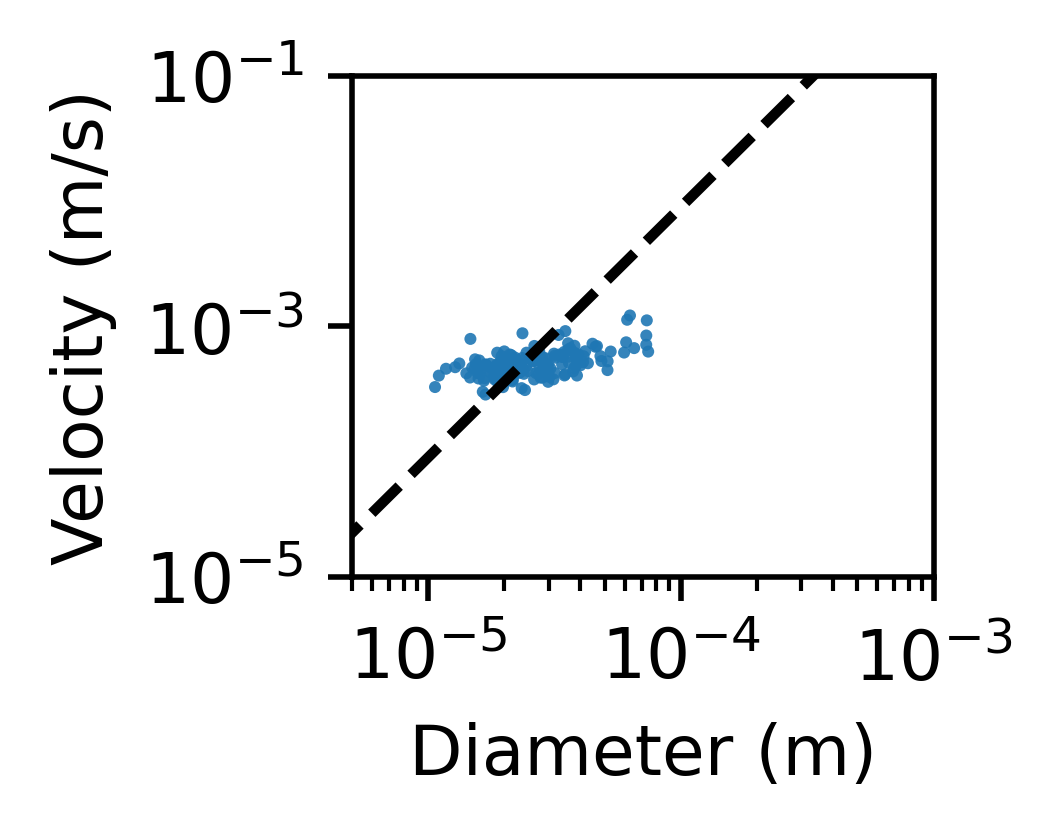

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 500

# Constants in meters and meters per second
g = 9.81  # Acceleration due to gravity (m/s^2)
Rs = 1.65  # Submerged specific gravity of the primary particles
dp = 1e-6
b1 = 20  # Shape coefficient b1
b2 = 1.5  # Shape coefficient b2
nu = 1e-6  # Kinematic viscosity (m^2/s)
C1 = 18  # Coefficient for Stokes' law


# Convert diameters and velocities to meters per second
all_diameters_corrected = [ad / 1000000 for ad in avg_concave_diameters]
all_velocities_corrected = [av / 1000000 for av in avg_velocities]

# Fractal dimensions to plot
nf_values = [3.0, 2.5, 2.0, 1.5]

# Diameter of floc (m)
df = np.logspace(-6, -1, 100)

# Function to calculate settling velocity using the given equation (Equation 11)
def settling_velocity(df, nf, g, Rs, dp, b1, b2, nu):
    numerator = g * Rs * df**(nf - 1)
    term1 = b1 * nu * dp**(nf - 3)
    term2 = b2 * np.sqrt(g * Rs * df**nf * dp**(nf - 3))
    return numerator / (term1 + term2)

# Function to calculate settling velocity using Stokes' law
def stokes_law(D):
    return (Rs * g * D**2) / (C1 * nu)

# Calculate Stokes' law velocity for each diameter in all_diameters_corrected
stokes_velocities = [stokes_law(d) for d in all_diameters_corrected]

# Calculate the ratio between actual velocities and Stokes' law velocities
velocity_ratios = np.array(all_velocities_corrected) / np.array(stokes_velocities)

plt.figure(figsize=(1.5,1.3))

# Plotting Stokes' law in black
ws_stokes = stokes_law(df)
plt.plot(df, ws_stokes, color='black', linestyle='--', label="Stokes' Law")


# Scatter plot with color map based on the velocity ratio
sc = plt.scatter(all_diameters_corrected, all_velocities_corrected,
                marker='o', s=3, alpha=0.9, edgecolor='none')

# Colorbar

plt.xscale('log')
plt.yscale('log')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Diameter (m)')
plt.ylim([0.00001, 0.1])
plt.xlim([0.000005, 0.001])
plt.show()

In [6]:
import pandas as pd

data = {
    "Diameter (m)": all_diameters_corrected,
    "Velocity (m/s)": all_velocities_corrected
}
df = pd.DataFrame(data)

# Saving the DataFrame to the specified Excel file path
file_path = '/Users/braydennoh/Downloads/clayDI.xlsx'
df.to_excel(file_path, index=False)

NameError: name 'avg_prediction' is not defined

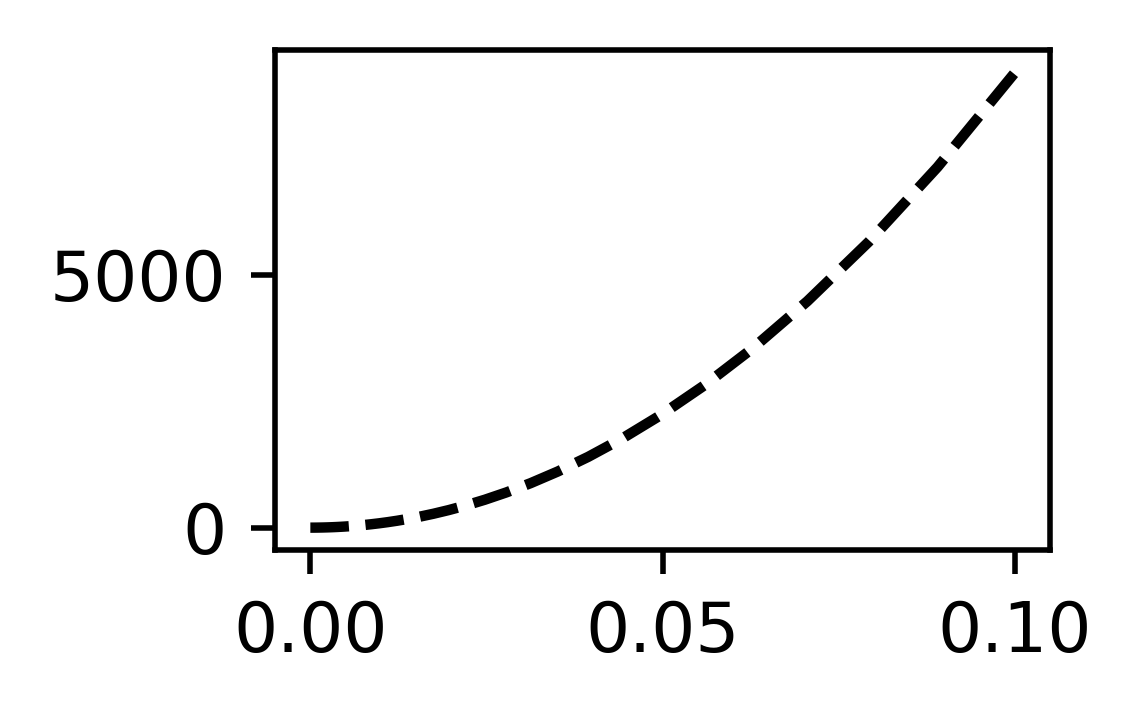

In [14]:
plt.figure(figsize=(2,1.3))

# Plotting Stokes' law in black
ws_stokes = stokes_law(df)
plt.plot(df, ws_stokes, color='black', linestyle='--', label="Stokes' Law")

# Filter the data where avg_aggregate == 1
filter_mask = np.array(avg_prediction) == 1
filtered_diameters = np.array(all_diameters_corrected)[filter_mask]
filtered_velocities = np.array(all_velocities_corrected)[filter_mask]
filtered_fractal_dimensions = np.array(avg_in_fractal_dimensions)[filter_mask]
filtered_avg_porosity = np.array(avg_porosity)[filter_mask]

# Scatter plot with color map based on the velocity ratio
sc = plt.scatter(filtered_diameters, filtered_velocities, c=filtered_fractal_dimensions,
                 cmap='viridis', marker='o', s=3, alpha=0.9, edgecolor='none')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('silica (0) floc (1)')

plt.xscale('log')
plt.yscale('log')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Diameter (m)')
plt.ylim([0.0001, 0.1])
plt.xlim([0.000005, 0.001])
plt.show()

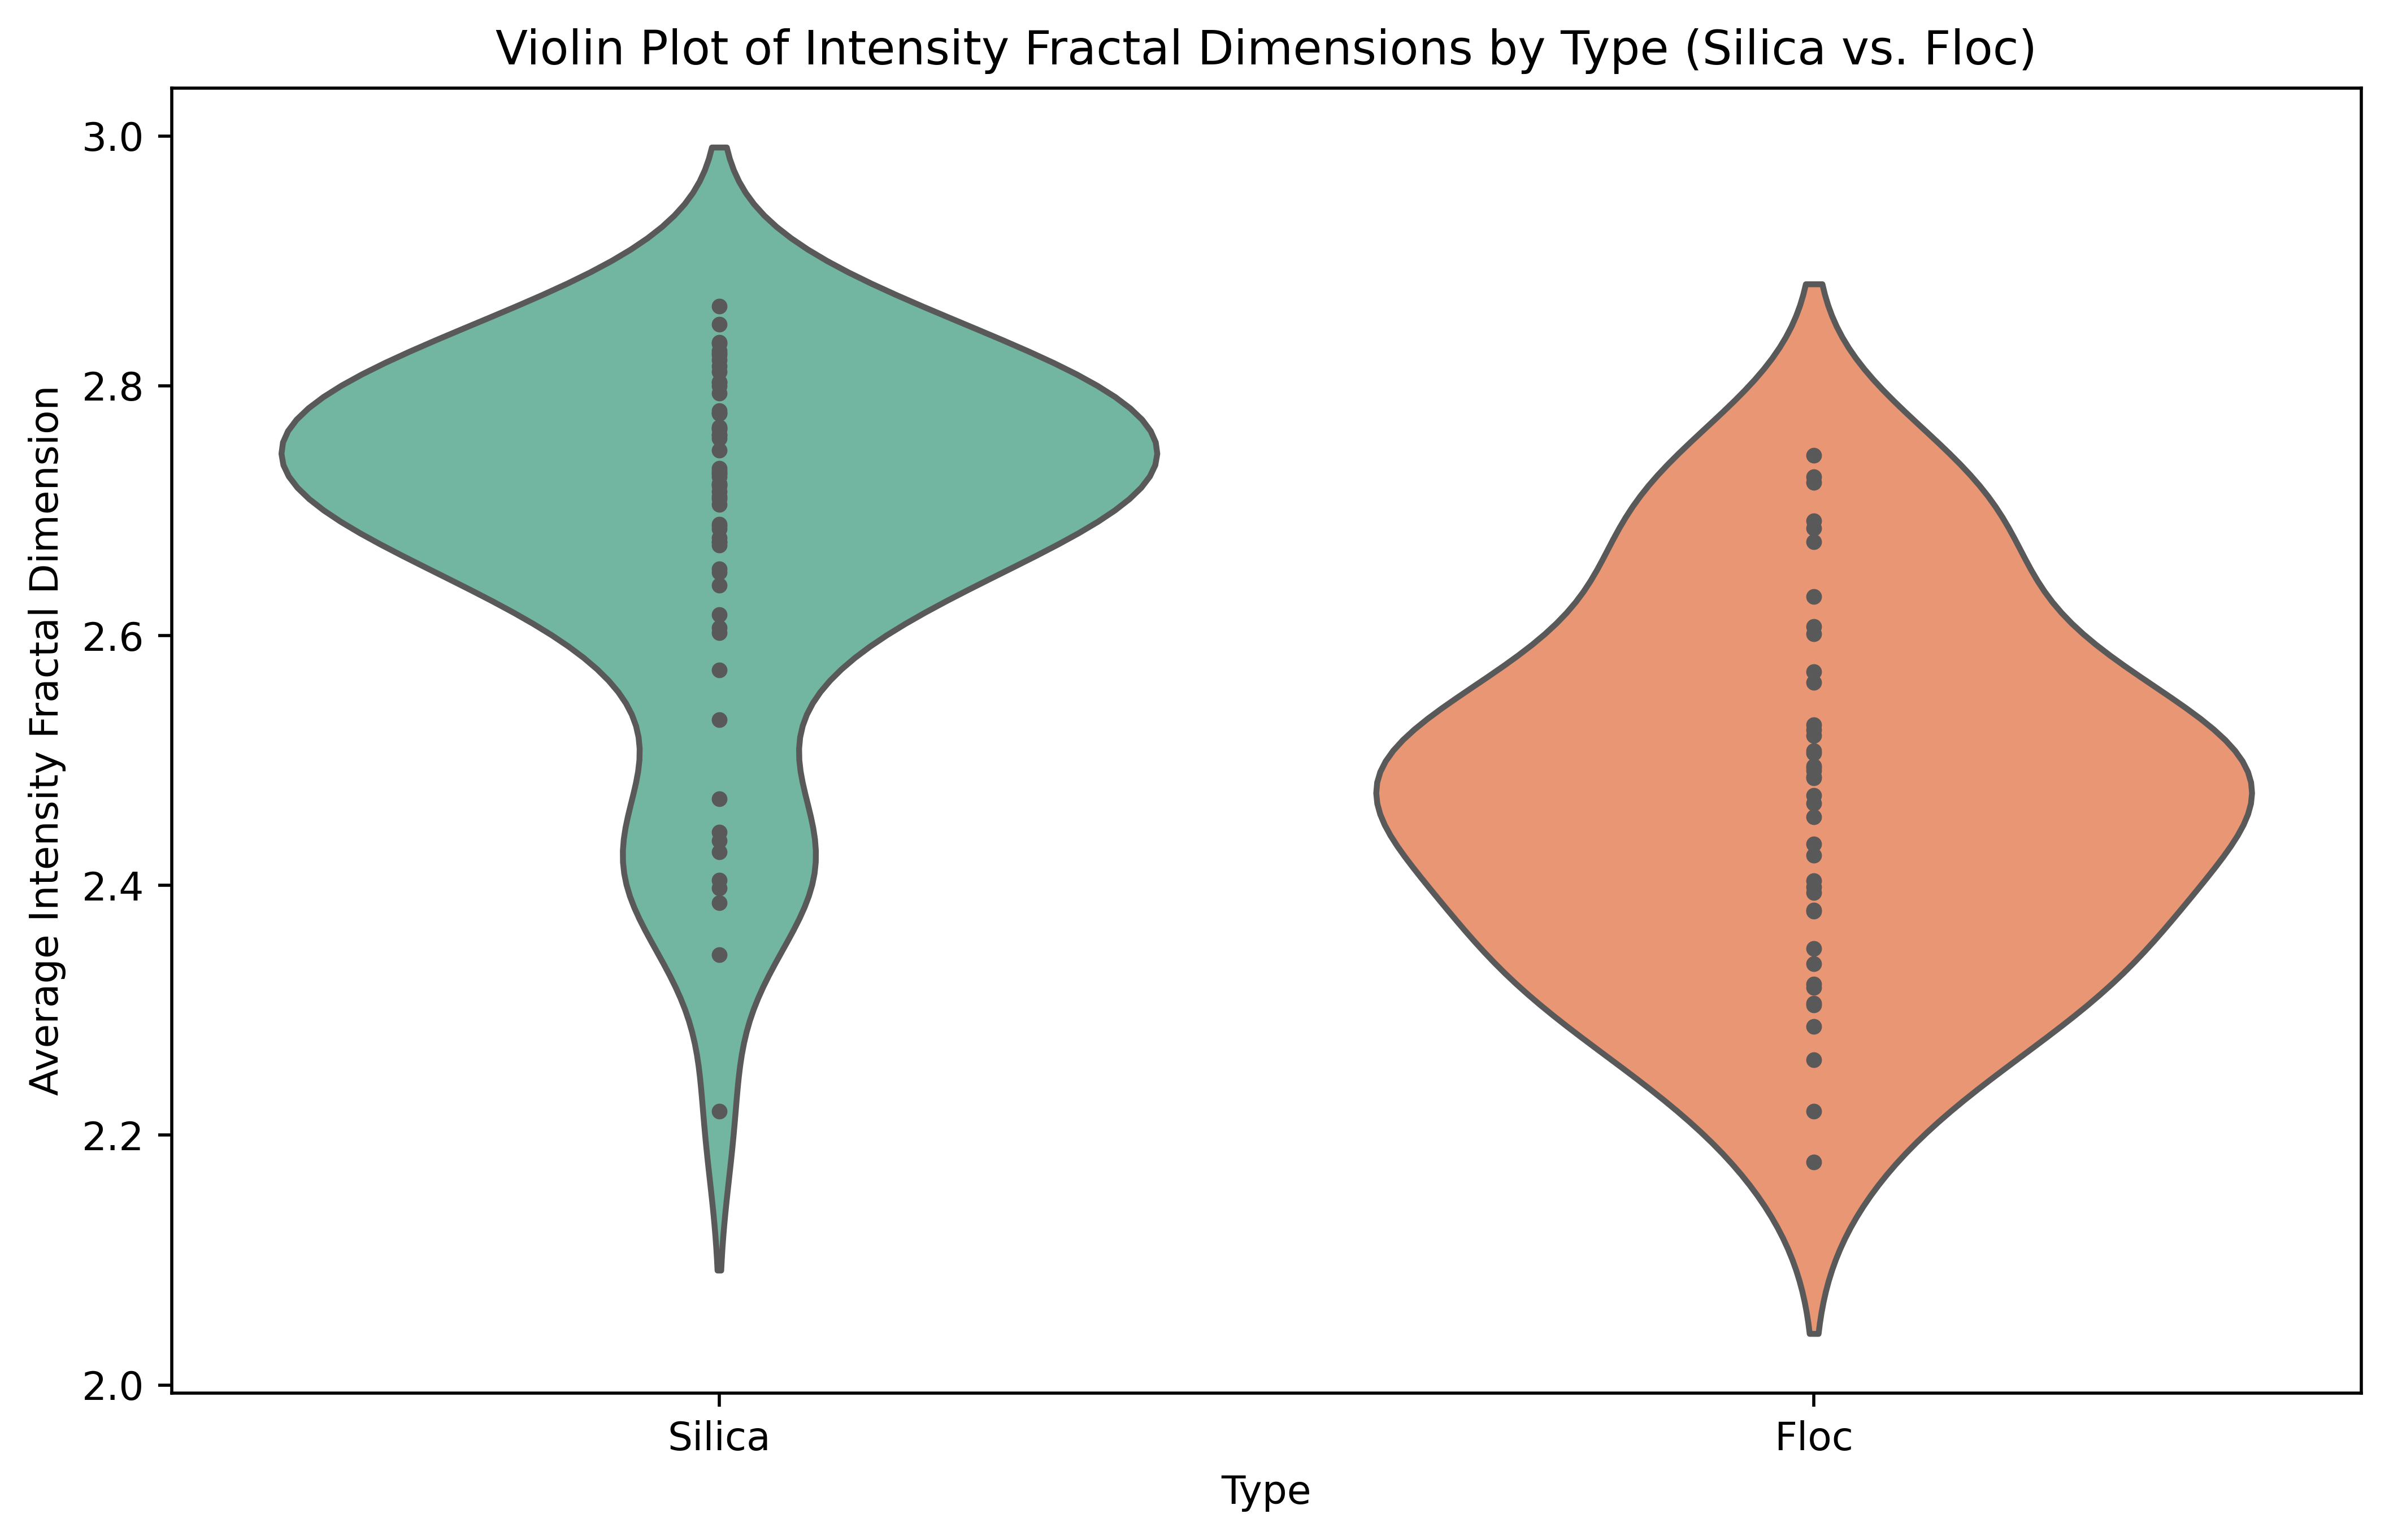

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate the `avg_in_fractal_dimensions` based on `avg_prediction`
silica_fractal_dimensions = [avg_in_fractal_dimensions[i] for i in range(len(avg_prediction)) if avg_prediction[i] == 0]
floc_fractal_dimensions = [avg_in_fractal_dimensions[i] for i in range(len(avg_prediction)) if avg_prediction[i] == 1]

# Prepare the data for plotting
data = silica_fractal_dimensions + floc_fractal_dimensions
labels = ['Silica'] * len(silica_fractal_dimensions) + ['Floc'] * len(floc_fractal_dimensions)

# Create a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=labels, y=data, inner="point", scale="width", palette="Set2")

# Add labels and title
plt.xlabel('Type')
plt.ylabel('Average Intensity Fractal Dimension')
plt.title('Violin Plot of Intensity Fractal Dimensions by Type (Silica vs. Floc)')

# Show the plot
plt.show()


In [ ]:
np.median(avg_fractal_dimensions)

2.6477084168445955

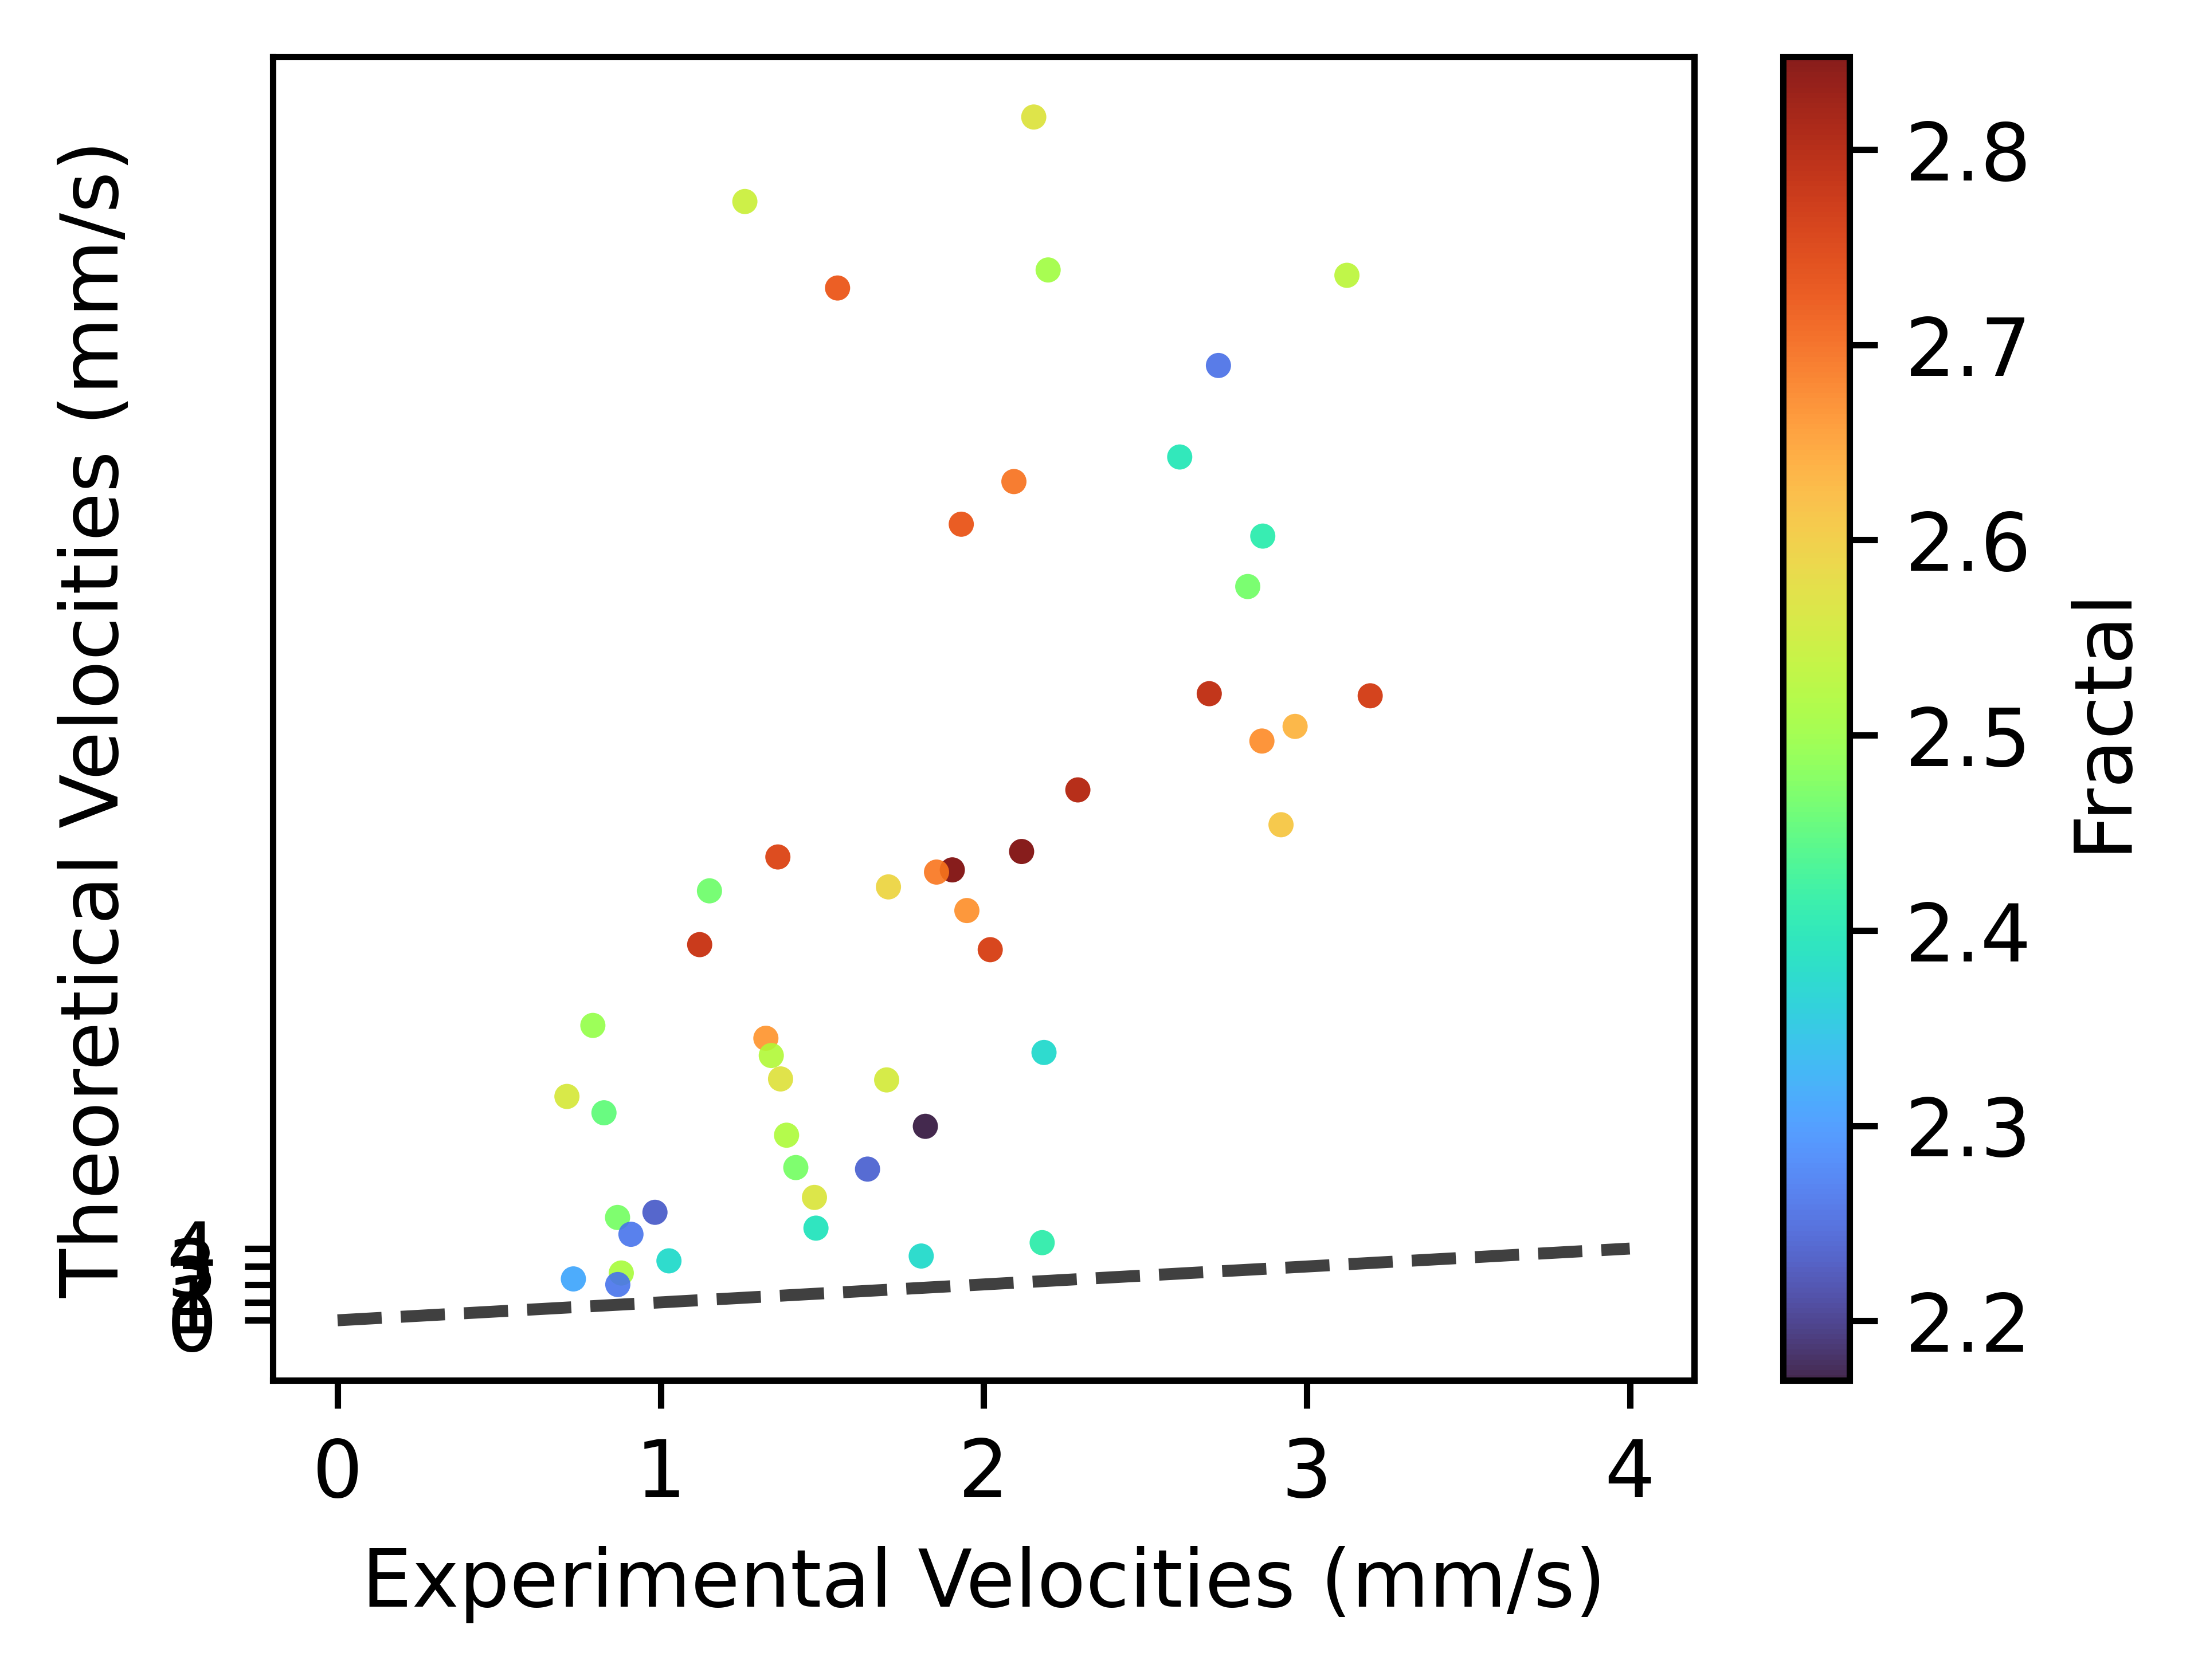

In [ ]:
def stokes_law(D):
    return (Rs * g * D**2) / (C1 * nu)


all_diameters_corrected = np.array(all_diameters_corrected)  
ws_values_corrected_mps = (Rs * g * all_diameters_corrected**2) / (C1 * nu)
ws_values_corrected_mmps = ws_values_corrected_mps * 1000
all_velocities_corrected_mmps = np.array(all_velocities_corrected) * 1000

# Create the figure
plt.figure(figsize=(4,3))

# Scatter plot with color map based on the velocity ratio
sc = plt.scatter(all_velocities_corrected_mmps, ws_values_corrected_mmps, c=avg_in_fractal_dimensions,
                 cmap='turbo', marker='o', s=10, alpha=0.9, edgecolor='none')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Fractal')

# Plot the y = x line for reference
min_val = 0  # Minimum value
max_val = 4  # Maximum value (now in mm/s)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x', alpha=0.75)  # Dashed line

plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 1, 2, 3, 4])

# Add labels, title, and legend
plt.xlabel('Experimental Velocities (mm/s)')
plt.ylabel('Theoretical Velocities (mm/s)')
# Show the plot
plt.show()

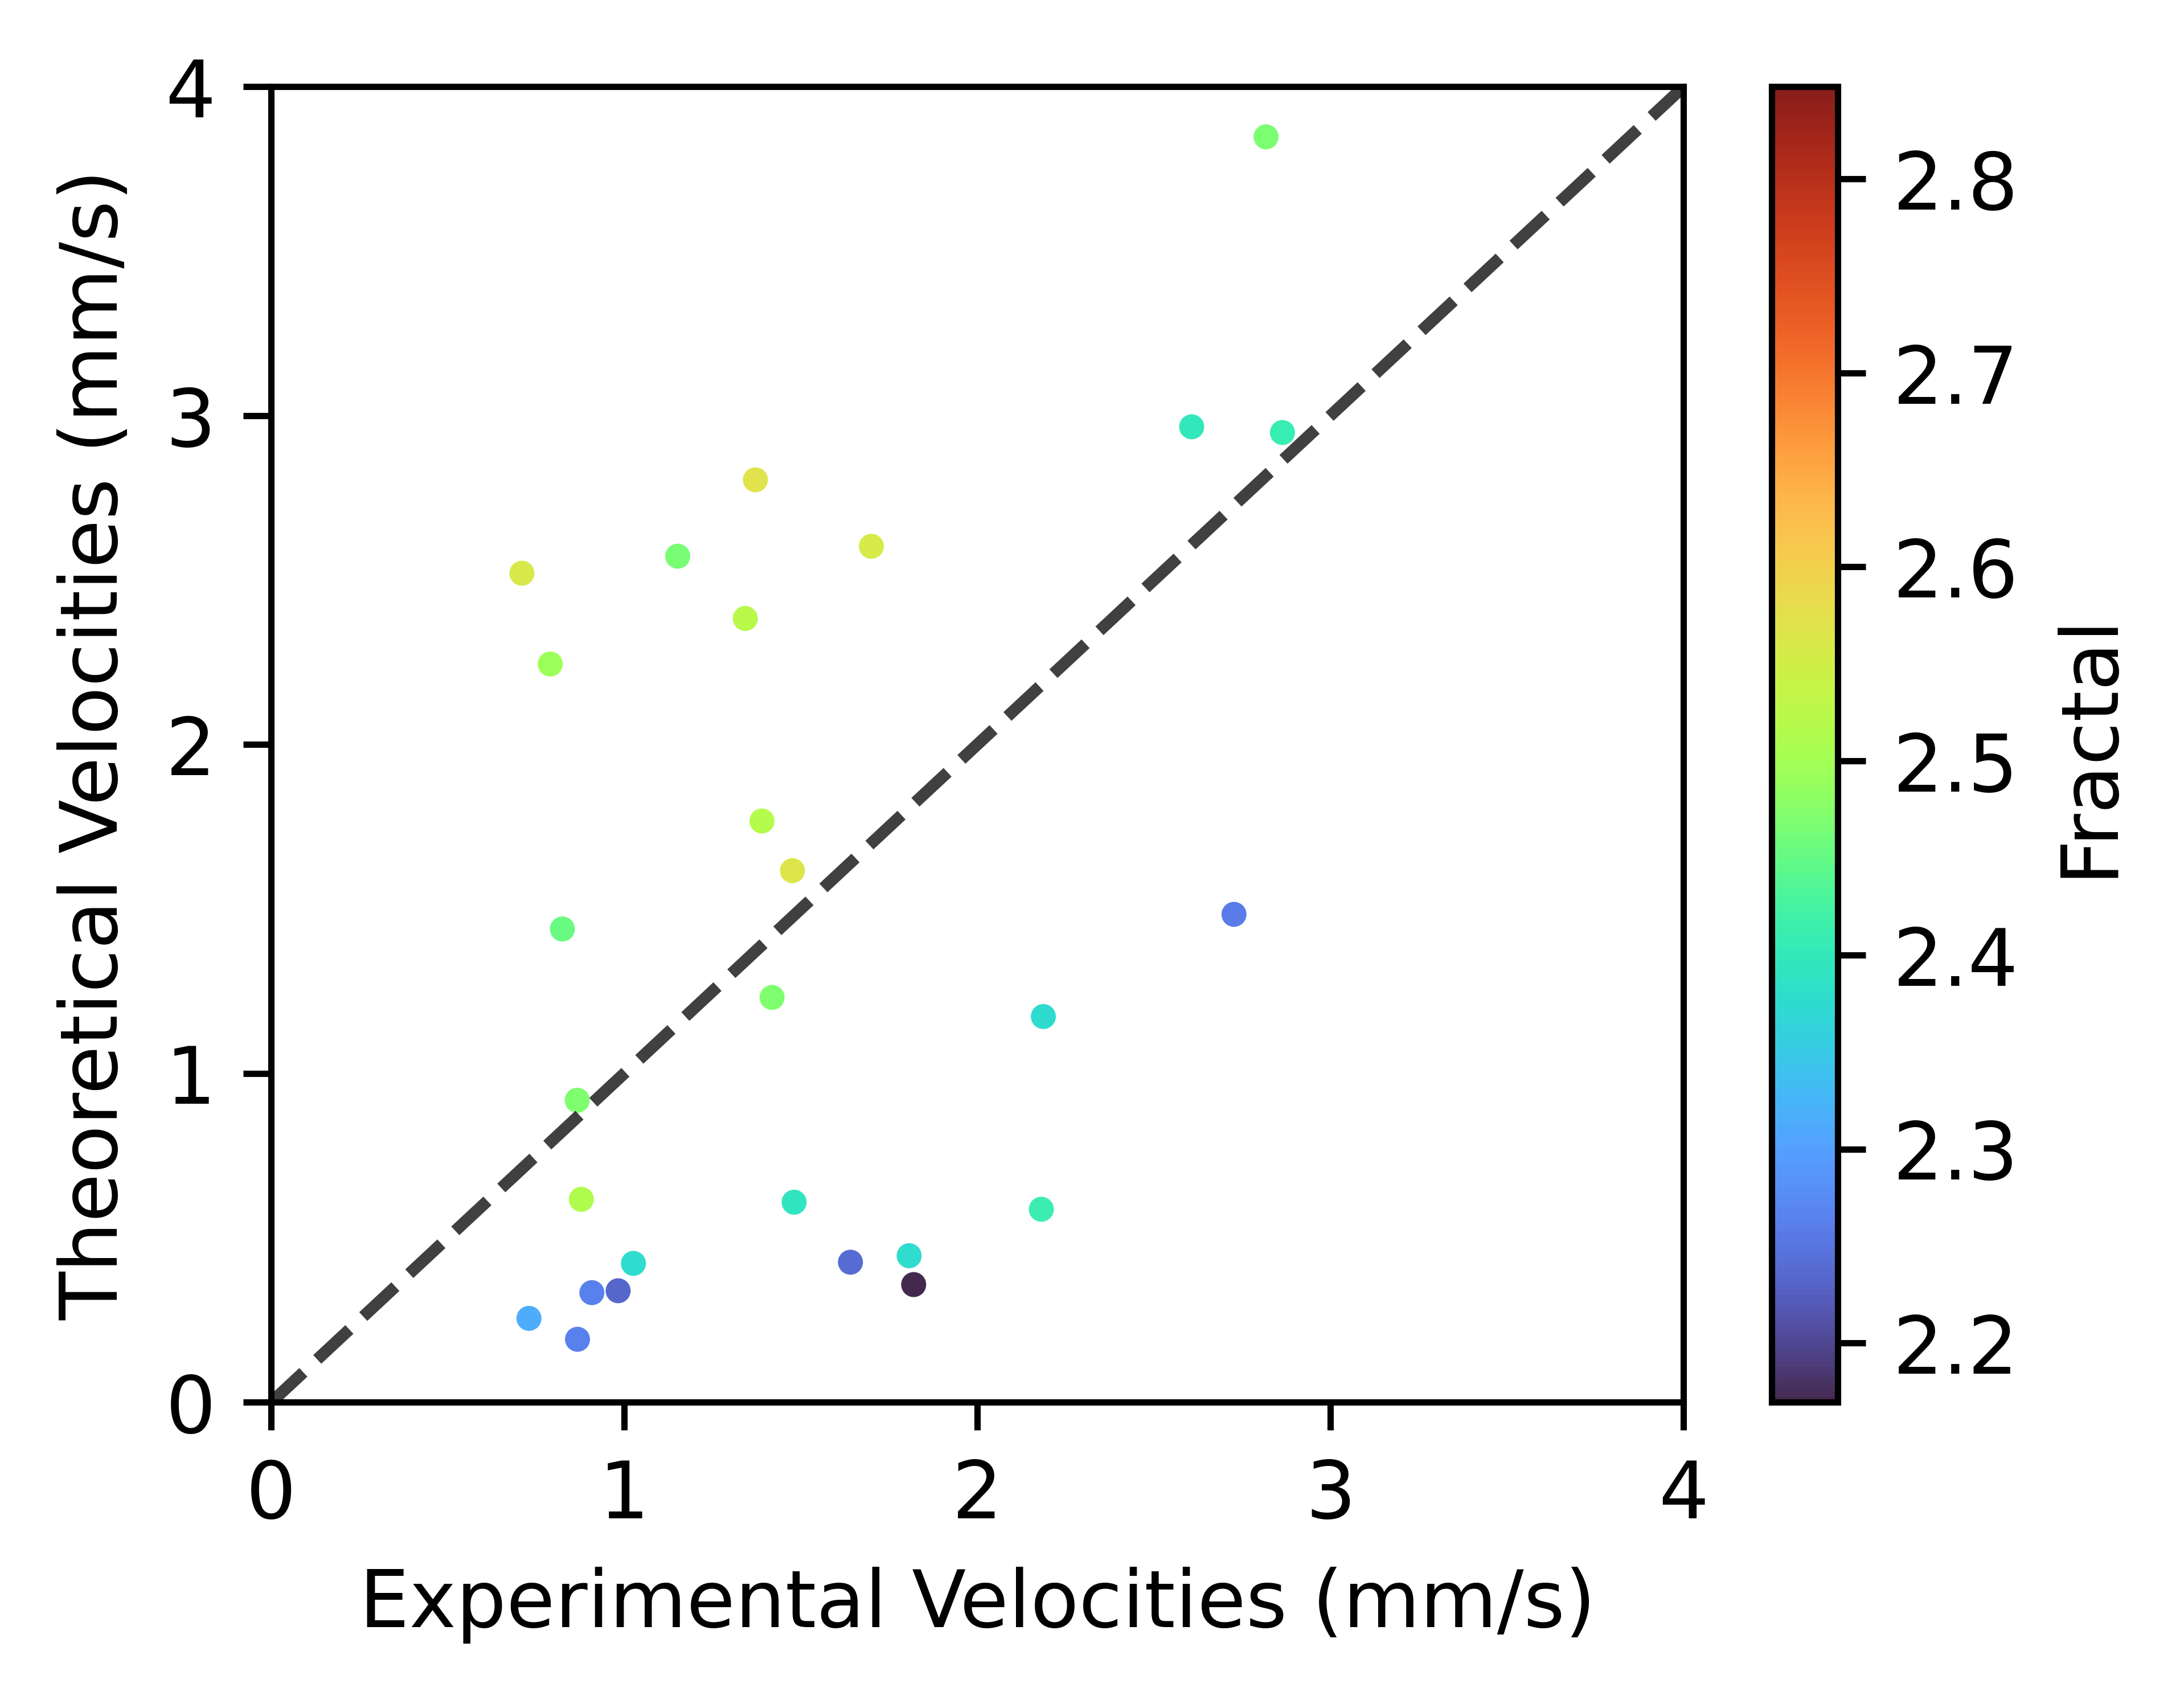

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # m/s^2
Rs = 1.65  # Submerged specific gravity
b1 = 22  # Shape coefficient
omega = 0.5  # Some omega constant
nu = 1e-6  # Kinematic viscosity (m^2/s)
dp = 1e-6 # Particle diameter in meters (constant)


ws_values_corrected_mps = (Rs * g * dp**2 / (b1 * omega * nu)) * (all_diameters_corrected / dp)**(avg_fractal_dimensions - 1)



all_diameters_corrected = np.array(all_diameters_corrected)  # Given particle diameters
avg_fractal_dimensions = np.array(avg_in_fractal_dimensions) 

# Convert both theoretical and experimental velocities from m/s to mm/s
ws_values_corrected_mmps = ws_values_corrected_mps * 1000
all_velocities_corrected_mmps = np.array(all_velocities_corrected) * 1000

# Create the figure
plt.figure(figsize=(4,3))

# Scatter plot with color map based on the velocity ratio
sc = plt.scatter(all_velocities_corrected_mmps, ws_values_corrected_mmps, c=avg_in_fractal_dimensions,
                 cmap='turbo', marker='o', s=10, alpha=0.9, edgecolor='none')

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Fractal')

# Plot the y = x line for reference
min_val = 0  # Minimum value
max_val = 4  # Maximum value (now in mm/s)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x', alpha=0.75)  # Dashed line

# Set the same limits and ticks for both axes
plt.xlim([0, 4])
plt.ylim([0, 4])
plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 1, 2, 3, 4])

# Add labels, title, and legend
plt.xlabel('Experimental Velocities (mm/s)')
plt.ylabel('Theoretical Velocities (mm/s)')
# Show the plot
plt.show()

/var/folders/pv/vxz_z6x905j13byjd_vxl_br0000gn/T/ipykernel_71496/2768061105.py:44: RuntimeWarning: divide by zero encountered in divide
  ws_values_corrected_mps = (Rs * g * dp**2 / (b1 * omega * nu)) * (all_diameters_corrected / dp)**(avg_fractal_dimensions - 1)


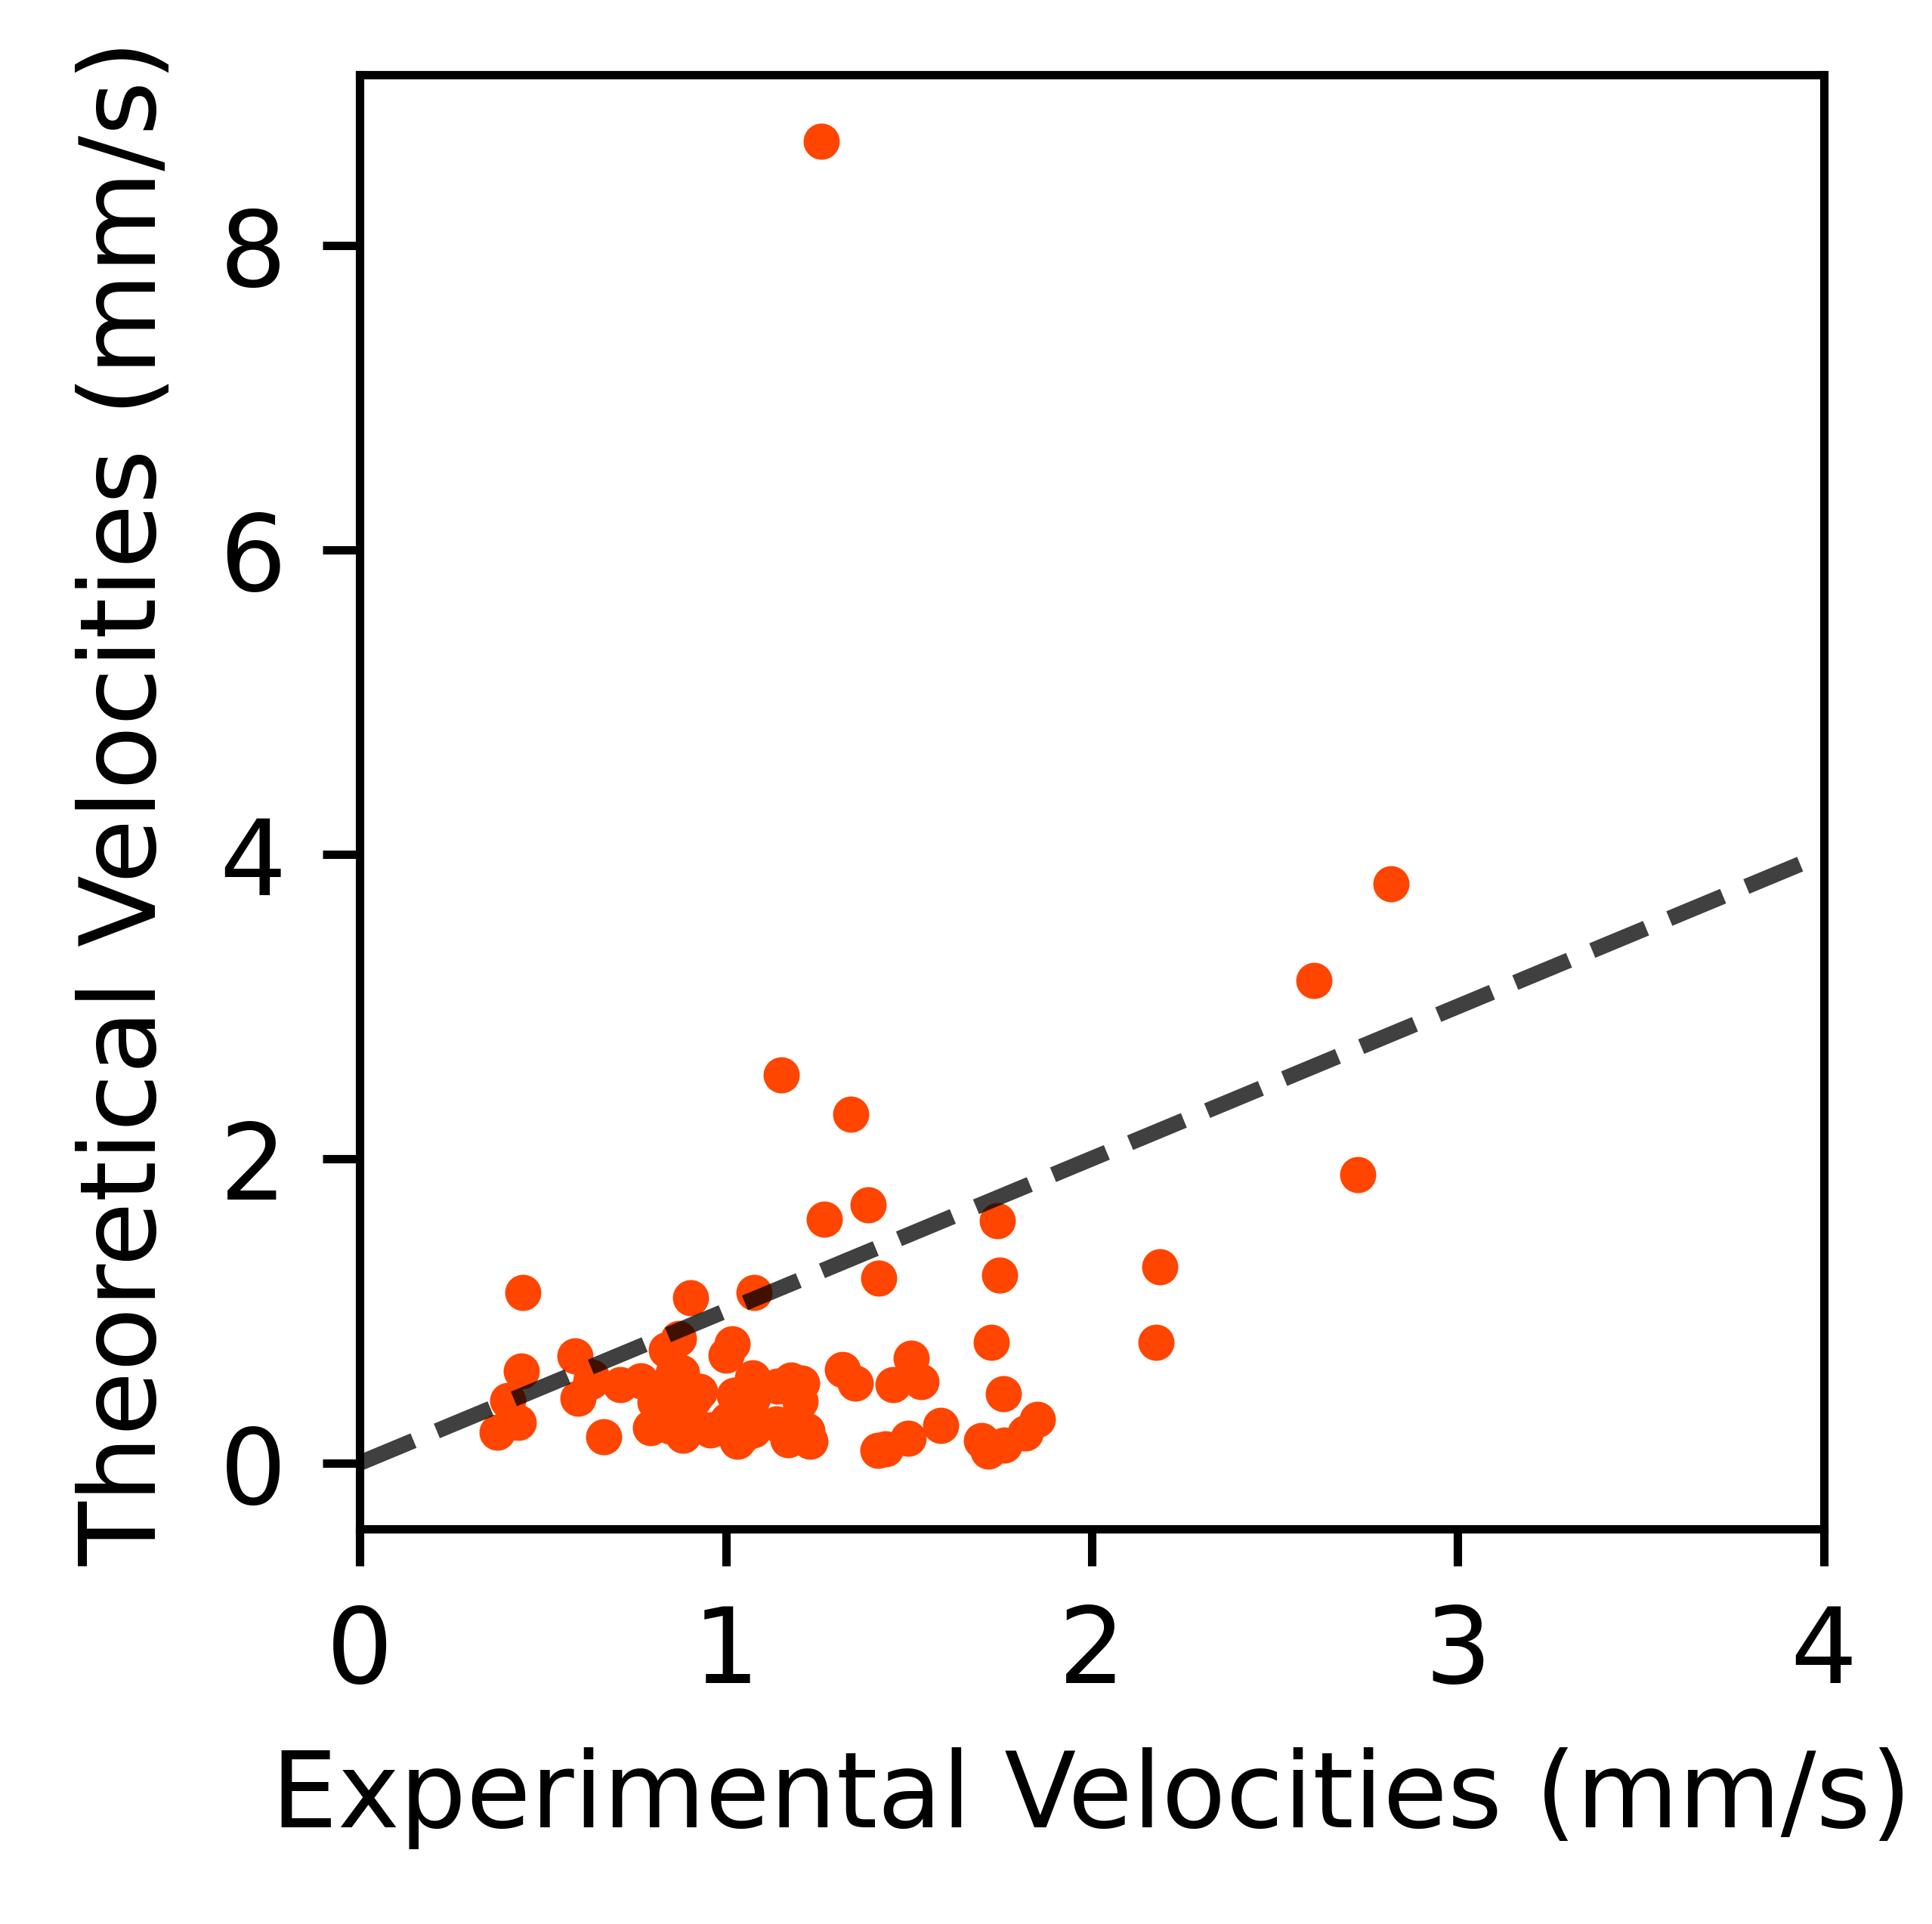

In [ ]:
import numpy as np

avg_fractal_dimensions = np.array(avg_fractal_dimensions)

# Define the combined function to calculate Omega directly from avg_fractal_dimensions
def calculate_omega_from_avg_fractal_dimensions(nf):
    # Handle potential divide by zero and invalid operations
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate xi_max^(-2)
        part1 = (1 / 56) * ((3 * nf - 5) / (23 - 9 * nf))
        part2 = (2 / (3 - nf)) - (3 / 2)
        exponent = (1 / 3) * part2
        xi_max_squared_inverse = (1 / 16) * (part1 ** exponent)
        
        # Calculate xi
        xi = np.sqrt(1 / xi_max_squared_inverse)
        
        # Calculate Omega
        numerator = 2 * xi**2 * (1 - (np.tanh(xi) / xi))
        denominator = 2 * xi**2 + 3 * (1 - (np.tanh(xi) / xi))
        omega = numerator / denominator
        
        # Replace NaN values with 0
        omega[np.isnan(omega)] = 0
    
    return omega

# Calculate Omega for each value in avg_fractal_dimensions
omega = calculate_omega_from_avg_fractal_dimensions(avg_fractal_dimensions)

all_diameters_corrected = np.array(all_diameters_corrected)  # Given particle diameters
avg_fractal_dimensions = np.array(avg_fractal_dimensions) 

dp = 3e-6 # Particle diameter in meters (constant)
g = 9.81  # m/s^2
Rs = 1.65  # Submerged specific gravity
b1 = 22  # Shape coefficient,.compute_omega(dp, avg_fractal_dimensions, all_diameters_corrected)
nu = 1e-6  # Kinematic viscosity (m^2/s)
omega = omega
# Particle diameters for ws_values calculation (assumed from corrected diameters)
all_diameters_corrected = np.array(all_diameters_corrected)  # Given particle diameters
avg_fractal_dimensions = np.array(avg_fractal_dimensions) 
# Calculate ws_values for the corrected diameters in m/s
ws_values_corrected_mps = (Rs * g * dp**2 / (b1 * omega * nu)) * (all_diameters_corrected / dp)**(avg_fractal_dimensions - 1)

# Convert both theoretical and experimental velocities from m/s to mm/s
ws_values_corrected_mmps = ws_values_corrected_mps * 1000
all_velocities_corrected_mmps = np.array(all_velocities_corrected) * 1000

# Create the figure
plt.figure(figsize=(2.5,2.5))
# Scatter plot for theoretical ws_values vs experimental velocities (in mm/s)
plt.scatter(all_velocities_corrected_mmps, ws_values_corrected_mmps, color='orangered', s=6, label='Theoretical Ws')

# Plot the y = x line for reference
min_val = 0  # Minimum value
max_val = 4  # Maximum value (now in mm/s)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x', alpha=0.75)  # Dashed line
plt.xlim([0,4])
#plt.ylim([0,4])

# Add labels, title, and legend
plt.xlabel('Experimental Velocities (mm/s)')
plt.ylabel('Theoretical Velocities (mm/s)')
# Show the plot
plt.show()

In [ ]:
all_diameters_corrected = np.array(all_diameters_corrected)
avg_fractal_dimensions = np.array(avg_fractal_dimensions) 

dp = 5e-5

phi= (all_diameters_corrected/dp)**(avg_fractal_dimensions-3)
phi

array([2.32080117e+00, 3.70848877e-02, 2.88009779e-02, 7.73697023e-03,
       6.23629005e-01, 6.83497689e-02, 5.41130292e-02,            nan,
       2.12438672e+00, 9.12190002e-02, 8.80709361e+00, 7.65133617e-01,
       6.65167538e-01, 2.48038340e+00,            nan,            nan,
                  nan,            nan, 1.68154725e+00, 2.77651855e+00,
                  nan,            nan, 4.24769686e-01,            nan,
       1.74510335e+00, 1.66225698e-01,            nan, 3.05429270e+00,
       3.00172056e-01, 2.43401113e+00, 2.84669752e-01,            nan,
       8.03505783e-01, 2.84269361e-02, 1.63792305e-02, 3.98718998e-01,
       9.48889831e-02, 1.30720335e-01, 2.42868342e-02, 1.67119449e+00,
                  nan, 1.01315420e-02, 3.13273161e-01, 1.17054561e-02,
                  nan, 1.77569269e-02,            nan,            nan,
       4.68586121e-01, 9.44383798e-02, 5.40271518e-01, 1.29308079e-02,
                  nan, 8.71325431e-03, 3.66703365e-02, 3.33688158e-01,
      

In [ ]:
filter_mask = np.array(avg_aggregate) == 1
filtered_diameters = np.array(all_diameters_corrected)[filter_mask]
filtered_velocities = np.array(all_velocities_corrected)[filter_mask]
filtered_fractal_dimensions = np.array(avg_per_fractal_dimensions)[filter_mask]
filtered_avg_porosity = np.array(avg_porosity)[filter_mask]


avg_fractal_dimensions = np.array(filtered_velocities)
all_diameters_corrected = np.array(filtered_diameters)  # Given particle diameters
dp = 5e-5

phi= (all_diameters_corrected/dp)**avg_fractal_dimensions-1



# Define the combined function to calculate Omega directly from avg_fractal_dimensions
def calculate_omega_from_avg_fractal_dimensions(nf):
    # Handle potential divide by zero and invalid operations
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate xi_max^(-2)
        part1 = (1 / 56) * ((3 * nf - 5) / (23 - 9 * nf))
        part2 = (2 / (3 - nf)) - (3 / 2)
        exponent = (1 / 3) * part2
        xi_max_squared_inverse = (1 / 16) * (part1 ** exponent)
        
        # Calculate xi
        xi = np.sqrt(1 / xi_max_squared_inverse)
        
        # Calculate Omega
        numerator = 2 * xi**2 * (1 - (np.tanh(xi) / xi))
        denominator = 2 * xi**2 + 3 * (1 - (np.tanh(xi) / xi))
        omega = numerator / denominator
        
        # Replace NaN values with 0
        omega[np.isnan(omega)] = 0
    
    return omega

# Calculate Omega for each value in avg_fractal_dimensions
omega = calculate_omega_from_avg_fractal_dimensions(avg_fractal_dimensions)

# Print the result
print(omega)

[0.         0.90803614 0.         0.90938011 0.         0.
 0.         0.         0.         0.906559   0.90495134 0.
 0.81762389 0.89038009 0.90721289 0.9031473  0.90434436 0.
 0.90846437 0.         0.90386404 0.         0.         0.
 0.         0.         0.87894603 0.         0.90710042 0.
 0.89072579 0.         0.         0.         0.9078058  0.
 0.         0.88419001 0.         0.9068717  0.90713146 0.
 0.         0.         0.         0.8823583  0.90937673 0.
 0.         0.89752073 0.         0.         0.90350128 0.88384006
 0.82200451 0.         0.90753563 0.90636155 0.         0.
 0.90024208 0.         0.90896549 0.         0.         0.89477327
 0.         0.89749569 0.90654839 0.         0.         0.896532
 0.88585552 0.         0.89332984 0.         0.         0.
 0.89727443 0.         0.         0.         0.90584618 0.
 0.         0.90745085 0.         0.         0.         0.
 0.         0.         0.         0.         0.90651763 0.
 0.89553422 0.88913592 0.88741212 

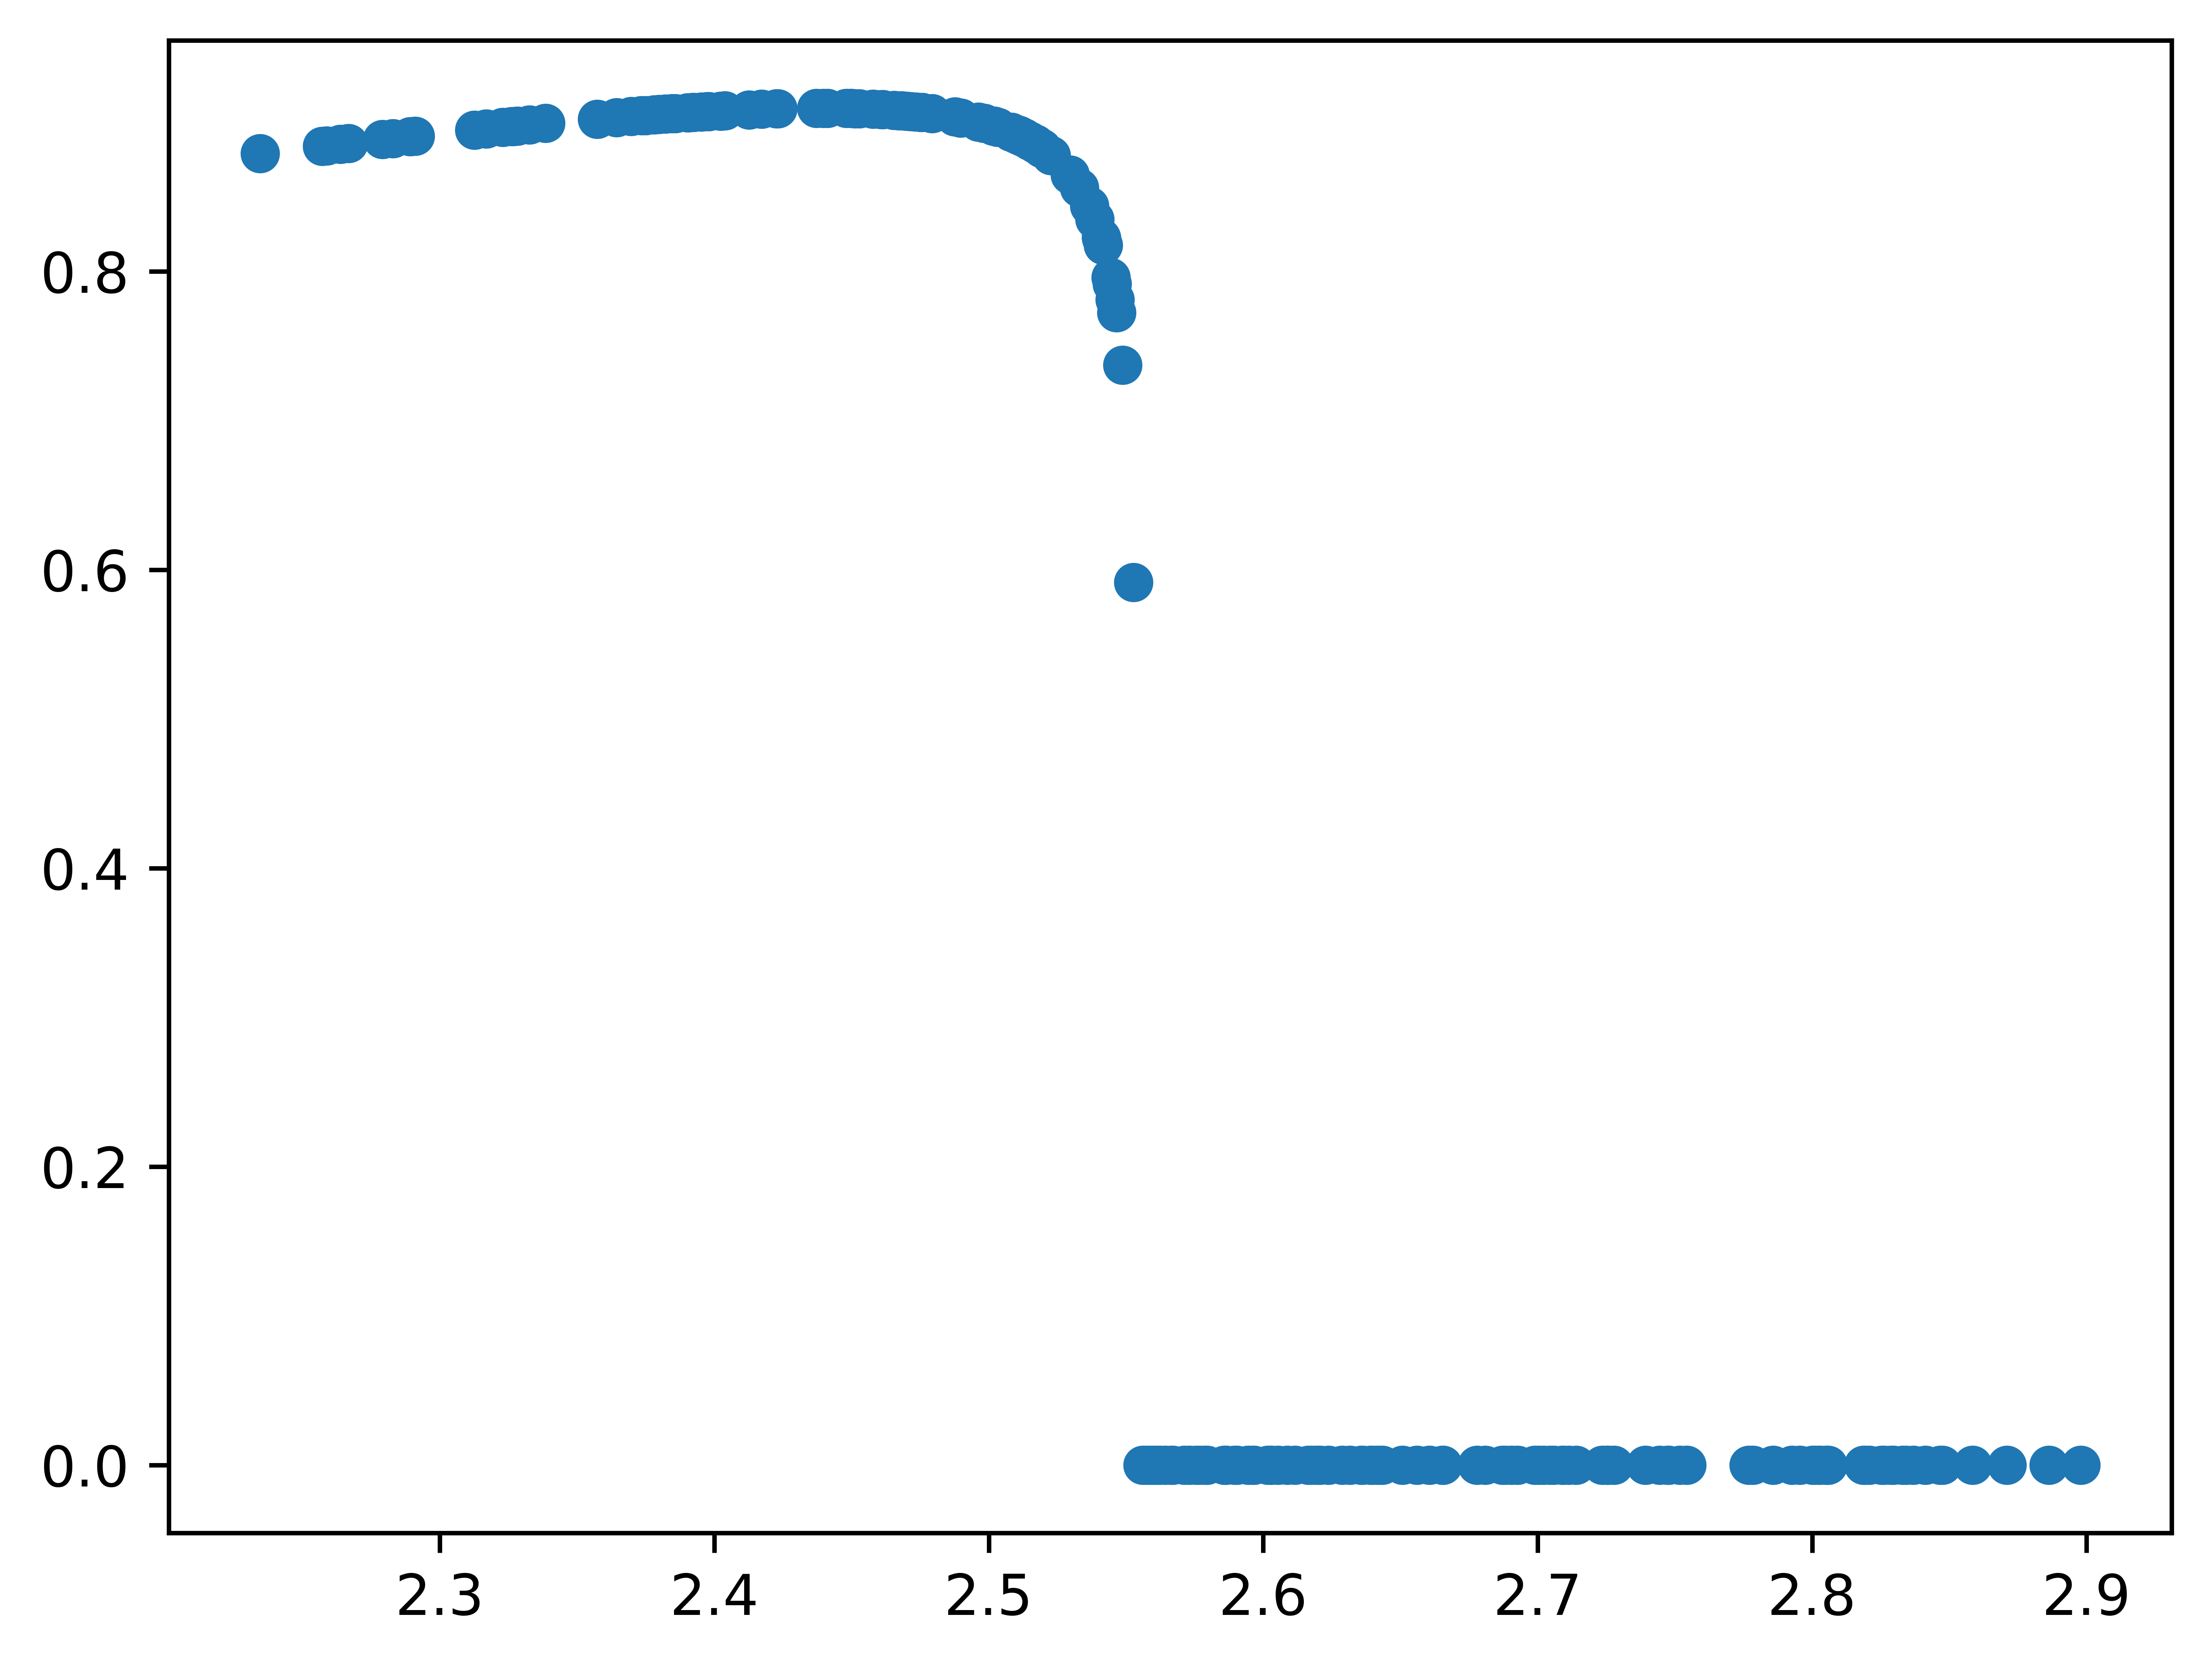

In [ ]:
plt.scatter(avg_fractal_dimensions,omega )

In [ ]:
np.median(all_diameters_corrected)

0.00011894281835893883

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate settling velocity using the given equation
def settling_velocity(df, nf, g, Rs, dp, b1, b2, nu):
    numerator = g * Rs * df ** (nf - 1)
    term1 = b1 * nu * dp ** (nf - 3)
    term2 = b2 * np.sqrt(g * Rs * df ** nf * dp ** (nf - 3))
    return numerator / (term1 + term2)

# Defining constants again
g = 9.81  # Acceleration due to gravity (m/s^2)
Rs = 1.65  # Submerged specific gravity of the primary particles
dp = 1e-5  # Particle diameter in meters
b1 = 10  # Shape coefficient b1
b2 = 0.5  # Shape coefficient b2
nu = 1e-6  # Kinematic viscosity (m^2/s)

# Scatter plot
plt.figure(figsize=(3, 2))
sc = plt.scatter(filtered_diameters, filtered_velocities, c=filtered_fractal_dimensions,
                 cmap='viridis_r', marker='o', s=10, alpha=0.8, edgecolor='none', vmin=2, vmax=3,zorder=10)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Fractal Dimension')

# Log scale for axes
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Diameter (m)')
plt.ylim([0.0001, 0.1])
plt.xlim([0.000005, 0.001])

# Calculate theoretical velocity for each data point
for d, v, nf in zip(filtered_diameters, filtered_velocities, filtered_fractal_dimensions):
    theoretical_velocity = settling_velocity(d, nf, g, Rs, dp, b1, b2, nu)
    plt.plot([d, d], [v, theoretical_velocity], 'r-', alpha=0.6,lw=1)  # Line between experimental and theoretical velocities

# Overlay model equation
df = np.linspace(0.000005, 0.005, 100)  # Diameter in meters
colors = plt.cm.viridis_r(np.linspace(0, 1, len(nf_values)))  # Blue theme for lines
for i, nf in enumerate(nf_values):
    ws = settling_velocity(df, nf, g, Rs, dp, b1, b2, nu)  # Settling velocity in m/s
    valid_indices = df >= min(df)
    plt.plot(df[valid_indices], ws[valid_indices], color=colors[i], label=f'nf = {nf:.1f}', zorder=1)
    
# Calculate the log differences and handle NaNs
log_differences = []

# Calculate the log differences between experimental and theoretical velocities
for d, v, nf in zip(filtered_diameters, filtered_velocities, filtered_fractal_dimensions):
    theoretical_velocity = settling_velocity(d, nf, g, Rs, dp, b1, b2, nu)
    
    # Ensure velocities are positive
    if v > 0 and theoretical_velocity > 0:
        log_diff = np.log(v) - np.log(theoretical_velocity)  # Log difference
        if not np.isnan(log_diff) and not np.isinf(log_diff):
            log_differences.append(log_diff)

# Calculate the normalized error as the average of squared log differences
num_data_points = len(log_differences)
if num_data_points > 0:
    normalized_error = np.sum(np.array(log_differences) ** 2) / num_data_points
    print(f"Normalized Error (Average of Squared Log Differences): {normalized_error:.6f}")
else:
    print("No valid log differences to calculate normalized error.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate settling velocity using the given equation
def settling_velocity(df, nf, g, Rs, dp, b1, b2, nu):
    numerator = g * Rs * df ** (nf - 1)
    term1 = b1 * nu * dp ** (nf - 3)
    term2 = b2 * np.sqrt(g * Rs * df ** nf * dp ** (nf - 3))
    return numerator / (term1 + term2)

# Function to calculate the normalized error
def calculate_normalized_error(dp, diameters, velocities, fractal_dimensions, g, Rs, b1, b2, nu):
    log_differences = []
    for d, v, nf in zip(diameters, velocities, fractal_dimensions):
        theoretical_velocity = settling_velocity(d, nf, g, Rs, dp, b1, b2, nu)
        if v > 0 and theoretical_velocity > 0:
            log_diff = np.log(v) - np.log(theoretical_velocity)
            if not np.isnan(log_diff) and not np.isinf(log_diff):
                log_differences.append(log_diff)
    if log_differences:
        return np.sum(np.array(log_differences) ** 2) / len(log_differences)
    else:
        return np.inf  # If no valid differences, return a high error

# Adaptive ABC parameters
n_samples = 10000  # Total number of samples
dp_min, dp_max = 1e-7, 5e-5  # Bounds for dp
b1_min, b1_max = 5, 6  # Bounds for b1
b2_min, b2_max = 0.9, 1  # Bounds for b2
epsilon_initial = 1.0  # Initial tolerance for error, start higher
epsilon_decay = 0.95  # Decay factor for epsilon
accepted_samples = []  # To store accepted (dp, b1, b2) samples

# Initialize sampling
dp_samples = np.random.uniform(dp_min, dp_max, n_samples)
errors = []

# Run the adaptive ABC algorithm
epsilon = epsilon_initial
for i in range(n_samples):
    dp = dp_samples[i]
    b1 = np.random.uniform(b1_min, b1_max)  # Stochastically sample b1
    b2 = np.random.uniform(b2_min, b2_max)  # Stochastically sample b2
    
    error = calculate_normalized_error(dp, filtered_diameters, filtered_velocities, filtered_fractal_dimensions, g, Rs, b1, b2, nu)
    errors.append(error)
    
    # Debugging: Print intermediate results
    #print(f"Iteration {i}, dp: {dp:.6e}, b1: {b1:.2f}, b2: {b2:.2f}, error: {error:.6f}, epsilon: {epsilon:.6f}")
    
    # Acceptance based on adaptive epsilon
    if error < epsilon:
        accepted_samples.append((dp, b1, b2))
    
    # Update epsilon adaptively to focus on better regions
    if i > 0 and i % 100 == 0:  # Adjust every 100 iterations
        epsilon = epsilon * epsilon_decay  # Reduce epsilon to tighten the acceptance criterion

accepted_dp, accepted_b1, accepted_b2 = zip(*accepted_samples)

plt.figure(figsize=(3, 2))
plt.hist(accepted_dp, bins=30, density=True, color='dodgerblue')
nanmedian_dp = np.nanmedian(accepted_dp)
plt.axvline(nanmedian_dp, color='red', linestyle='--', linewidth=2)
plt.xlabel('dp (m)')
plt.ylabel('Density')
plt.show()

best_dp_estimate = np.median(accepted_dp)
print(f"Best fitting dp estimate: {best_dp_estimate:.6e} m")

In [ ]:
accepted_dp_microns = np.array(accepted_dp) * 1e6
nanmedian_dp_microns = np.nanmedian(accepted_dp_microns)

# Plot histogram with x-axis in microns
plt.figure(figsize=(2, 1.5))
plt.hist(accepted_dp_microns, bins=30, density=True, color='dodgerblue')

# Plot vertical red dashed line at the nanmedian value
plt.axvline(nanmedian_dp_microns, color='red', linestyle='--', linewidth=2)

# Labels
plt.xlabel('dp (microns)')
plt.ylabel('Density')

# Show plot
plt.show()

# Best fitting dp estimate in microns
best_dp_estimate_microns = np.median(accepted_dp_microns)
print(f"Best fitting dp estimate: {best_dp_estimate_microns:.2f} microns")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the prior distribution for dp
dp_prior_mu = 1e-5  # Mean of the prior (center of the valid range)
dp_prior_sigma = 1e-5  # Standard deviation (broad range)

# Generate initial samples for dp from the prior distribution
n_samples = 50000  # Number of samples
dp_samples = np.random.normal(dp_prior_mu, dp_prior_sigma, n_samples)

# Ensure dp is within the valid range [1e-6, 1e-4]
dp_samples = dp_samples[(dp_samples >= 1e-6) & (dp_samples <= 1e-4)]

# Calculate likelihood of observed data for each sample
def calculate_likelihood(dp):
    theoretical_velocities = np.array([
        settling_velocity(d / 1000, nf, g, Rs, dp, b1, b2, nu) * 1000
        for d, nf in zip(all_diameters_corrected, avg_fractal_dimensions_rounded)
    ])
    log_exp_velocities = np.log10(all_velocities_corrected)
    log_theoretical_velocities = np.log10(theoretical_velocities)
    error_diff = log_exp_velocities - log_theoretical_velocities
    return np.exp(-np.nansum(np.abs(error_diff)))

# Calculate the likelihood for all dp samples
likelihoods = np.array([calculate_likelihood(dp) for dp in dp_samples])

# Posterior: combine the prior and the likelihood
posterior_probabilities = likelihoods * norm.pdf(dp_samples, dp_prior_mu, dp_prior_sigma)

# Normalize the posterior to sum to 1
posterior_probabilities /= np.sum(posterior_probabilities)

# Estimate the best dp as the mean of the posterior distribution
best_dp_bayes = np.sum(dp_samples * posterior_probabilities)
best_dp_bayes

# Visualize the posterior distribution
plt.figure(figsize=(2.5,2))
plt.hist(dp_samples, bins=50, weights=posterior_probabilities, label='Posterior Distribution')
plt.axvline(best_dp_bayes, color='red', linestyle='--', label=f'Best dp (Bayesian) = {best_dp_bayes:.2e}')
plt.xlabel('dp (m)')
plt.ylabel('Probability Density')
plt.show()
best_dp_bayes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pixels_per_micron = 0.4
fps = 30

# Initialize empty lists to store individual particle data
individual_particle_diameters = []
individual_velocities = []
individual_fractal_dimensions = []
individual_laplacians = []

# Iterate through each particle path in the data
for path in filtered_continuous_lines_data:
    particles = path.split(' -> ')
    for particle in particles:
        parts = particle.split(' in Frame ')
        particle_num = int(float(parts[0].split(' ')[1]))
        frame_num = int(parts[1])

        # Load the CSV file data for the current frame
        frame_data = load_frame_data(frame_num)

        # Extract the particle's data from the CSV file using its ParticleNum
        particle_data = frame_data[frame_data['ParticleNum'] == particle_num]

        if not particle_data.empty:
            # Extract velocity, fractal dimension, and individual particle diameters
            velocity = (particle_data['AverageVelocity'].values[0] / pixels_per_micron) * fps
            fractal_dimension = particle_data['FractalDimension'].values[0]
            laplacian = particle_data['LaplacianVariance'].values[0]

            # Extract ParticleDiameters, which can contain multiple values
            particle_diameters_value = particle_data['ParticleDiameters'].values[0]
            
            # Handle both cases: multiple diameters (comma-separated) or single diameter (float)
            if isinstance(particle_diameters_value, str):
                diameters = np.array([float(d) for d in particle_diameters_value.split(',')])
            else:
                diameters = np.array([particle_diameters_value], dtype=float)

            # Convert diameters from pixels to microns
            diameters_in_microns = diameters/0.4

            # Store the extracted values in individual lists
            individual_velocities.extend([velocity] * len(diameters_in_microns))
            individual_fractal_dimensions.extend([fractal_dimension] * len(diameters_in_microns))
            individual_laplacians.extend([laplacian] * len(diameters_in_microns))
            individual_particle_diameters.extend(diameters_in_microns)

NameError: name 'filtered_continuous_lines_data' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Filter out the data where individual_laplacians are greater than 1000
filtered_diameters = []
filtered_velocities = []
filtered_laplacians = []
filtered_fractal = []

for diameter, velocity, laplacian, fractal in zip(individual_particle_diameters, individual_velocities, individual_laplacians,individual_fractal_dimensions):
    if laplacian > 500:
        filtered_diameters.append(diameter / 1_000_000)  # Convert to meters
        filtered_velocities.append(velocity / 1_000_000)  # Convert to m/s
        filtered_laplacians.append(laplacian)
        filtered_fractal.append(fractal)

# Plotting
plt.figure(figsize=(2, 1.3))

plt.plot(df, ws_stokes, color='black', linestyle='--', label="Stokes' Law")

# Scatter plot with color map based on the laplacian value (filtered data)
sc = plt.scatter(filtered_diameters, filtered_velocities, marker='o', s=3, alpha=0.8, edgecolor='none')

# Set the scales to log-log
plt.xscale('log')
plt.yscale('log')

# Labels
plt.ylabel('Velocity (m/s)')
plt.xlabel('Diameter (m)')

plt.ylim([0.0001, 0.1])
plt.xlim([0.000001, 0.001])
# Show plot
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants in meters and meters per second
g = 9.81  # Acceleration due to gravity (m/s^2)
Rs = 1.65  # Submerged specific gravity of the primary particles
dp = 1e-5
b1 = 10  # Shape coefficient b1
b2 = 0.5  # Shape coefficient b2
nu = 1e-6  # Kinematic viscosity (m^2/s)

# Settling velocity function
def settling_velocity(df, nf, g, Rs, dp, b1, b2, nu):
    numerator = g * Rs * df ** (nf - 1)
    term1 = b1 * nu * dp ** (nf - 3)
    term2 = b2 * np.sqrt(g * Rs * df ** nf * dp ** (nf - 3))
    return numerator / (term1 + term2)

# Filter out the data where individual_laplacians are greater than 500
filtered_diameters = []
filtered_velocities = []
filtered_laplacians = []
filtered_fractal = []

for diameter, velocity, laplacian, fractal in zip(individual_particle_diameters, individual_velocities, individual_laplacians, individual_fractal_dimensions):
    if laplacian > 500:
        filtered_diameters.append(diameter / 1_000_000)  # Convert to meters
        filtered_velocities.append(velocity / 1_000_000)  # Convert to m/s
        filtered_laplacians.append(laplacian)
        filtered_fractal.append(fractal)

# Calculate the median velocity
median_velocity = np.nanmedian(filtered_velocities)

# Create df data for plotting the single nf value
df = np.linspace(0.000001, 0.001, 100)  # Diameter in meters

# Calculate the settling velocity for nf = 2.2
nf = 2.2
ws_nf_2_2 = settling_velocity(df, nf, g, Rs, dp, b1, b2, nu)

# Find the intersection point (where ws_nf_2_2 is closest to the median_velocity)
diff = np.abs(ws_nf_2_2 - median_velocity)
intersection_index = np.argmin(diff)
intersection_diameter = df[intersection_index]
intersection_velocity = ws_nf_2_2[intersection_index]

# Plotting
plt.figure(figsize=(3, 2))

# Plot the line for nf = 2.2
plt.plot(df, ws_nf_2_2, color='blue',lw=1.5)

# Plot the scatter plot with filtered data
sc = plt.scatter(filtered_diameters, filtered_velocities, color='black',marker='o', s=3, alpha=0.9, edgecolor='none')

# Plot horizontal line at median velocity
plt.axhline(median_velocity, color='red', linestyle='-', linewidth=1.5)

# Plot vertical line at the intersection diameter
plt.axvline(intersection_diameter, color='darkgreen', linewidth=1.5)

plt.axvline(2.5e-6, color='purple', linestyle='--', linewidth=1.5, label='2.5 Microns')

# Set the scales to log-log
plt.xscale('log')
plt.yscale('log')

# Labels
plt.ylabel('Velocity (m/s)')
plt.xlabel('Diameter (m)')

# Set plot limits
plt.ylim([0.00005, 0.01])
plt.xlim([0.0000005, 0.001])

# Show plot
plt.show()

NameError: name 'individual_particle_diameters' is not defined

In [ ]:
print(median_velocity)

In [ ]:
left_diameters = [d for d in filtered_diameters if d < intersection_diameter]

# Calculate the median of the filtered diameters
median_left_diameters = np.nanmedian(left_diameters)
median_left_diameters

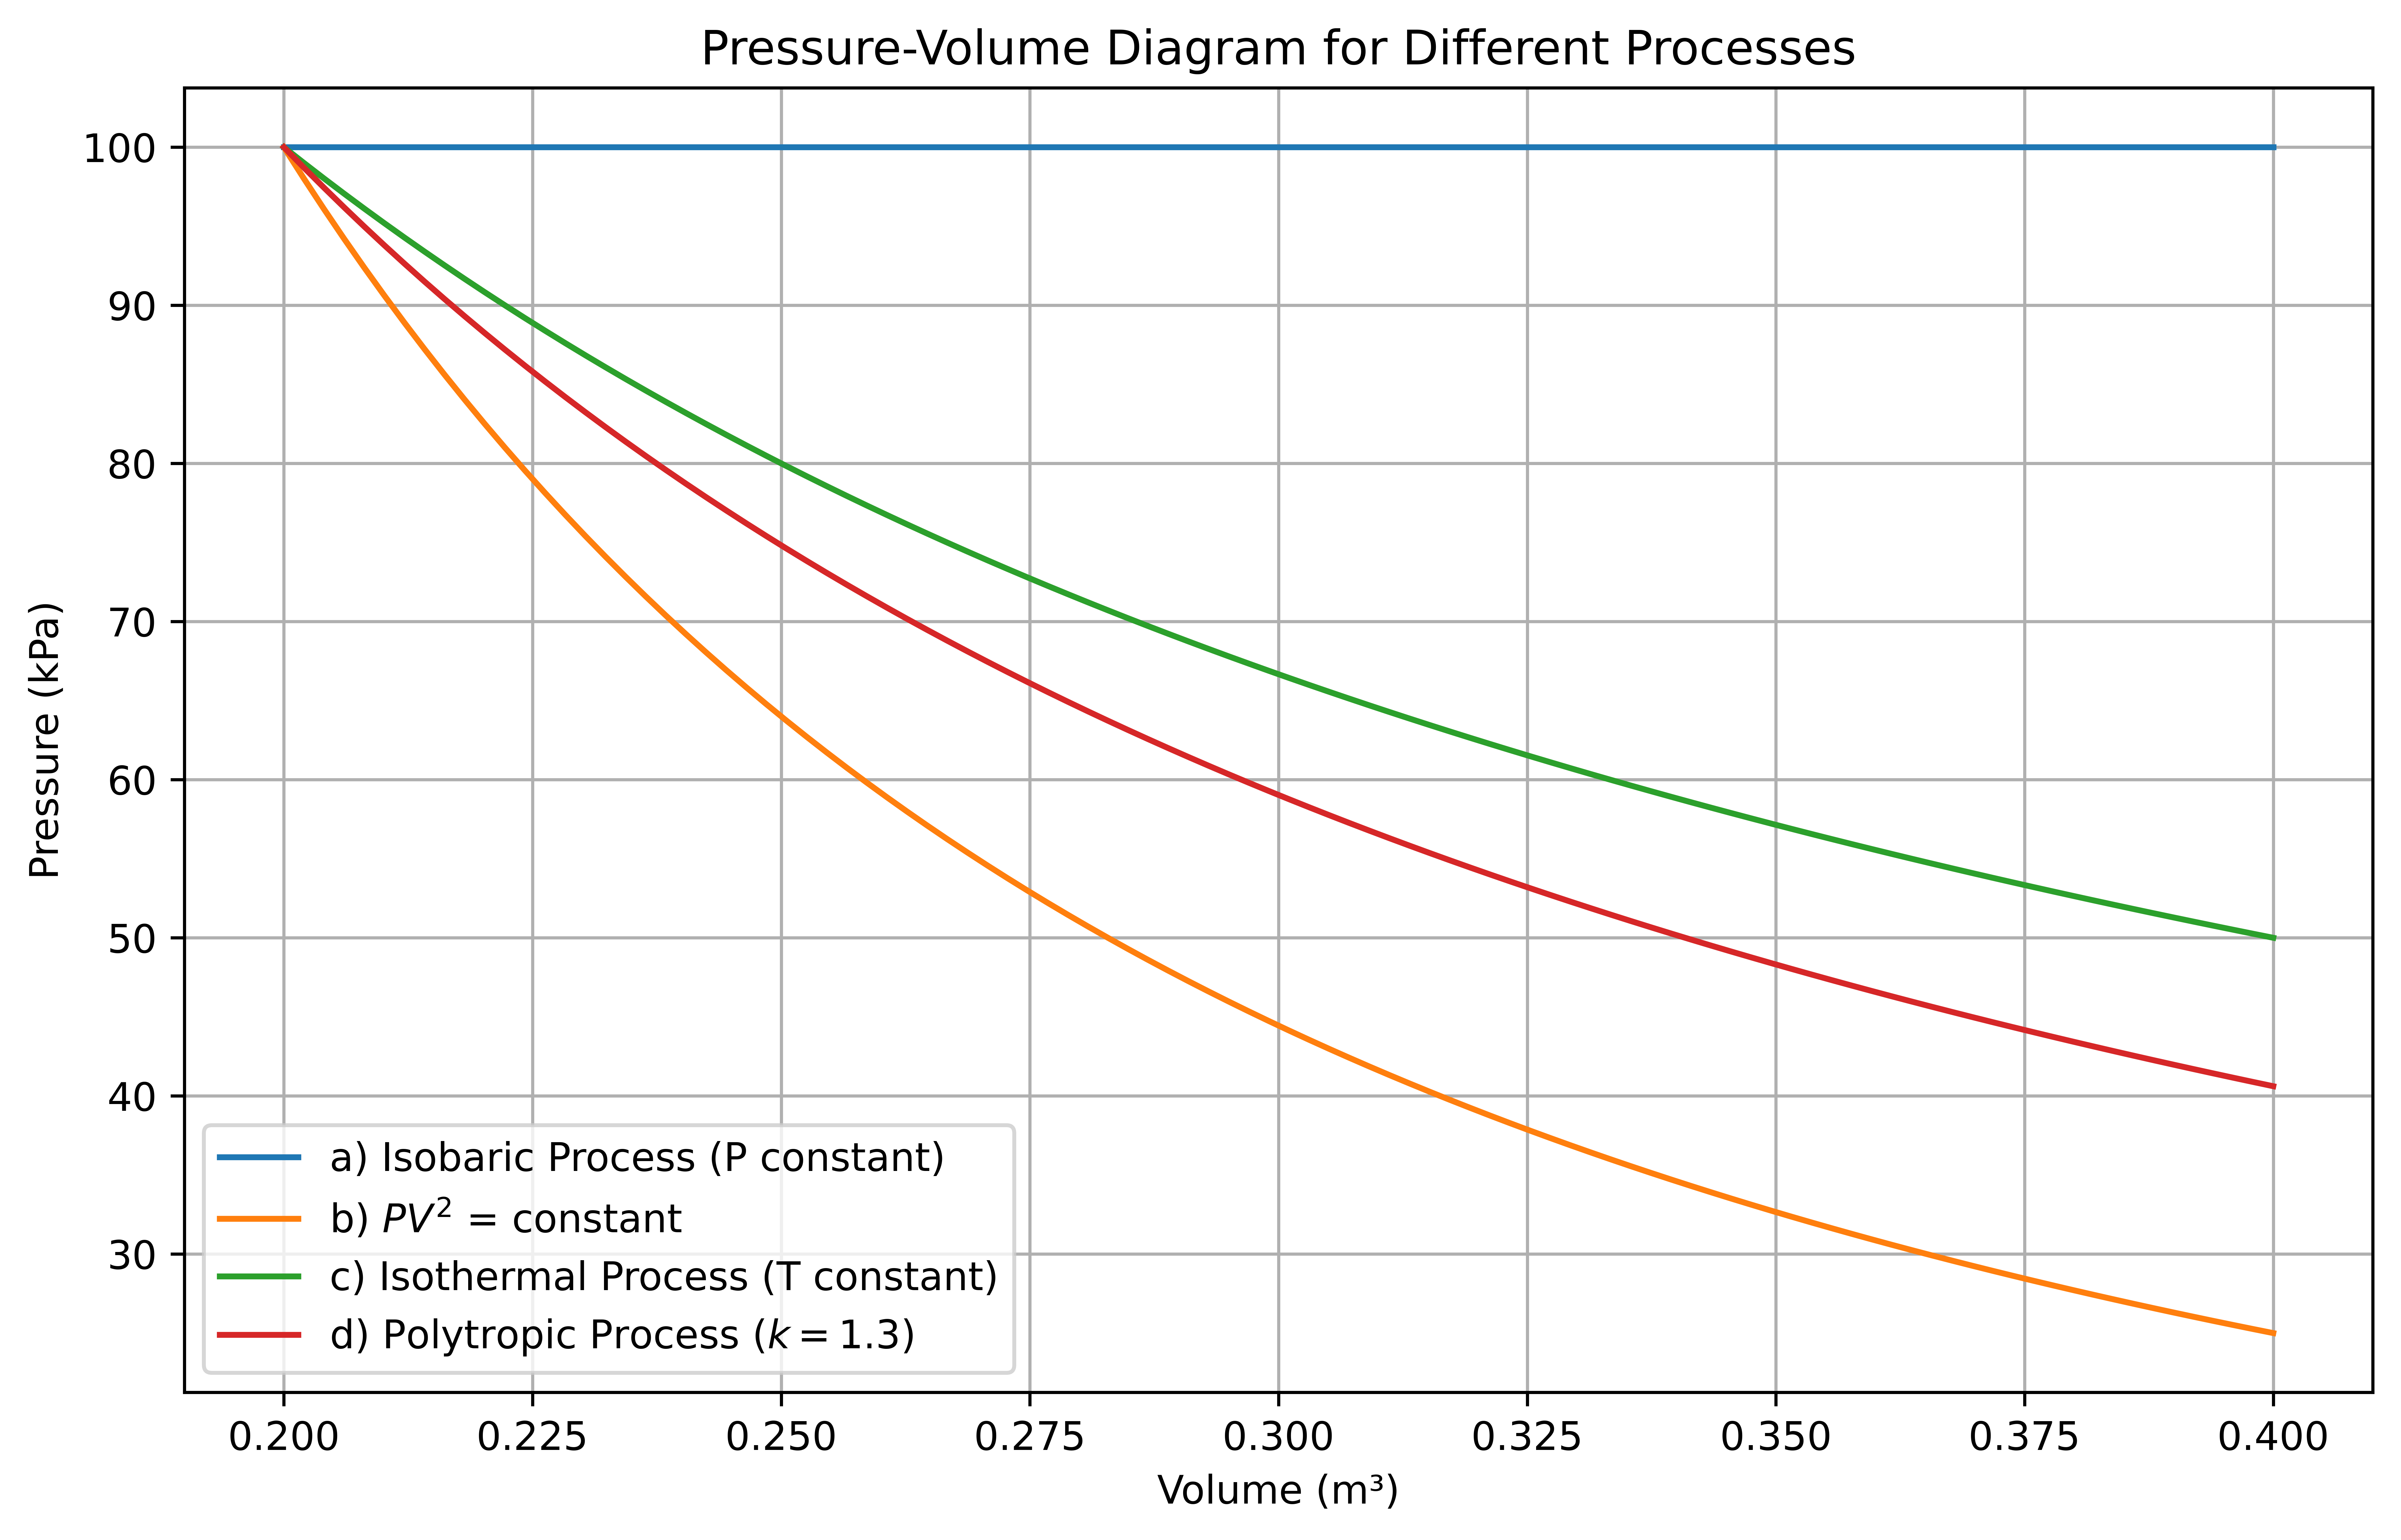

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Given initial conditions
V1 = 0.2  # Initial volume in cubic meters
V2 = 0.4  # Final volume in cubic meters
P1 = 100000  # Initial pressure in Pascals (0.1 MPa)

# Create an array of volume values from V1 to V2
V = np.linspace(V1, V2, 100)

# Process a) Isobaric (Constant Pressure)
P_a = np.full_like(V, P1)  # Pressure remains constant

# Process b) PV^2 = constant
C_b = P1 * V1**2  # Calculate the constant
P_b = C_b / V**2  # Pressure as a function of volume

# Process c) Isothermal (PV = constant)
C_c = P1 * V1  # Calculate the constant
P_c = C_c / V  # Pressure as a function of volume

# Process d) Polytropic Process (PV^k = constant with k = 1.3)
k = 1.3
C_d = P1 * V1**k  # Calculate the constant
P_d = C_d / V**k  # Pressure as a function of volume

# Plotting the P-V diagrams
plt.figure(figsize=(10, 6))

plt.plot(V, P_a / 1000, label='a) Isobaric Process (P constant)')
plt.plot(V, P_b / 1000, label=r'b) $PV^2$ = constant')
plt.plot(V, P_c / 1000, label='c) Isothermal Process (T constant)')
plt.plot(V, P_d / 1000, label=r'd) Polytropic Process ($k=1.3$)')

# Adding titles and labels
plt.title('Pressure-Volume Diagram for Different Processes')
plt.xlabel('Volume (m³)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


In [ ]:
import numpy as np
import scipy.interpolate
from scipy.spatial import distance
from tqdm import trange
import numba

class Channel:
    """Class for Channel objects"""

    def __init__(self, x, y, z, W, D):
        """Initialize Channel object

        :param x: x-coordinate of centerline
        :param y: y-coordinate of centerline
        :param z: z-coordinate of centerline
        :param W: channel width
        :param D: channel depth
        """
        self.x = x
        self.y = y
        self.z = z
        self.W = W
        self.D = D

class Cutoff:
    """Class for Cutoff objects"""

    def __init__(self, x, y, z, W, D):
        """Initialize Cutoff object

        :param x: x-coordinate of centerline
        :param y: y-coordinate of centerline
        :param z: z-coordinate of centerline
        :param W: channel width
        :param D: channel depth
        """
        self.x = x
        self.y = y
        self.z = z
        self.W = W
        self.D = D

class ChannelBelt:
    """Class for ChannelBelt objects"""

    def __init__(self, channels, cutoffs, cl_times, cutoff_times):
        """Initialize ChannelBelt object

        :param channels: list of Channel objects
        :param cutoffs: list of Cutoff objects
        :param cl_times: list of ages of Channel objects (in years)
        :param cutoff_times: list of ages of Cutoff objects
        """
        self.channels = channels
        self.cutoffs = cutoffs
        self.cl_times = cl_times
        self.cutoff_times = cutoff_times

    def migrate(self, nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor):
        """Method for computing migration rates along channel centerlines and moving the centerlines accordingly

        :param nit: number of iterations
        :param saved_ts: which time steps will be saved; e.g., if saved_ts = 10, every tenth time step will be saved
        :param deltas: distance between nodes on centerline
        :param pad: padding (number of nodepoints along centerline)
        :param crdist: threshold distance at which cutoffs occur
        :param depths: array of channel depths (can vary across iterations)
        :param Cfs: array of dimensionless Chezy friction factors (can vary across iterations)
        :param kl: migration rate constant (m/s)
        :param kv: vertical slope-dependent erosion rate constant (m/s)
        :param dt: time step (s)
        :param dens: density of fluid (kg/m3)
        :param t1: time step when incision starts
        :param t2: time step when lateral migration starts
        :param t3: time step when aggradation starts
        :param aggr_factor: aggradation factor
        """
        channel = self.channels[-1]  # first channel is the same as last channel of input
        x = channel.x
        y = channel.y
        z = channel.z
        W = channel.W
        D = channel.D
        k = 1.0  # constant in HK equation
        xc = []  # initialize cutoff coordinates
        # determine age of last channel:
        if len(self.cl_times) > 0:
            last_cl_time = self.cl_times[-1]
        else:
            last_cl_time = 0
        dx, dy, dz, ds, s = compute_derivatives(x, y, z)
        slope = np.gradient(z) / ds
        # padding at the beginning can be shorter than padding at the downstream end:
        pad1 = int(pad / 10.0)
        if pad1 < 5:
            pad1 = 5
        omega = -1.0  # constant in migration rate calculation (Howard and Knutson, 1984)
        gamma = 2.5  # from Ikeda et al., 1981 and Howard and Knutson, 1984
        for itn in trange(nit):  # main loop
            D = depths[itn]
            Cf = Cfs[itn]
            x, y = migrate_one_step(x, y, z, W, kl, dt, k, Cf, D, pad, pad1, omega, gamma)
            x, y, z, xc, yc, zc = cut_off_cutoffs(x, y, z, s, crdist, deltas)  # find and execute cutoffs
            x, y, z, dx, dy, dz, ds, s = resample_centerline(x, y, z, deltas)  # resample centerline
            slope = np.gradient(z) / ds
            # for itn<=t1, z is unchanged; for itn>t1:
            if (itn > t1) & (itn <= t2):  # incision
                if np.min(np.abs(slope)) != 0:  # if slope is not zero
                    z = z + kv * dens * 9.81 * D * slope * dt
                else:
                    z = z - kv * dens * 9.81 * D * dt * 0.05  # if slope is zero
            if (itn > t2) & (itn <= t3):  # lateral migration
                if np.min(np.abs(slope)) != 0:  # if slope is not zero
                    # use the median slope to counterbalance incision:
                    z = z + kv * dens * 9.81 * D * slope * dt - kv * dens * 9.81 * D * np.median(slope) * dt
                else:
                    z = z  # no change in z
            if (itn > t3):  # aggradation
                if np.min(np.abs(slope)) != 0:  # if slope is not zero
                    # 'aggr_factor' should be larger than 1 so that this leads to overall aggradation:
                    z = z + kv * dens * 9.81 * D * slope * dt - aggr_factor * kv * dens * 9.81 * D * np.mean(slope) * dt
                else:
                    z = z + aggr_factor * dt
            if len(xc) > 0:  # save cutoff data
                self.cutoff_times.append(last_cl_time + (itn + 1) * dt / (365 * 24 * 60 * 60.0))
                cutoff = Cutoff(xc, yc, zc, W, D)  # create cutoff object
                self.cutoffs.append(cutoff)
            # saving centerlines (with the exception of first channel):
            if (np.mod(itn, saved_ts) == 0) & (itn > 0):
                self.cl_times.append(last_cl_time + (itn + 1) * dt / (365 * 24 * 60 * 60.0))
                channel = Channel(x, y, z, W, D)  # create channel object
                self.channels.append(channel)

def compute_derivatives(x, y, z):
    """Compute first derivatives of a curve (centerline)"""
    dx = np.gradient(x)
    dy = np.gradient(y)
    dz = np.gradient(z)
    ds = np.sqrt(dx**2 + dy**2 + dz**2)
    s = np.hstack((0, np.cumsum(ds[1:])))
    return dx, dy, dz, ds, s

def migrate_one_step(x, y, z, W, kl, dt, k, Cf, D, pad, pad1, omega, gamma):
    """Migrate centerline during one time step"""
    ns = len(x)
    curv = compute_curvature(x, y)
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    sinuosity = s[-1] / (x[-1] - x[0])
    curv = W * curv  # dimensionless curvature
    R0 = kl * curv  # simple linear relationship between curvature and nominal migration rate
    alpha = k * 2 * Cf / D  # exponent for convolution function G
    R1 = compute_migration_rate(pad, ns, ds, alpha, omega, gamma, R0)
    R1 = sinuosity ** (-2 / 3.0) * R1
    # calculate new centerline coordinates:
    dy_ds = dy[pad1:ns - pad + 1] / ds[pad1:ns - pad + 1]
    dx_ds = dx[pad1:ns - pad + 1] / ds[pad1:ns - pad + 1]
    x[pad1:ns - pad + 1] = x[pad1:ns - pad + 1] + R1[pad1:ns - pad + 1] * dy_ds * dt
    y[pad1:ns - pad + 1] = y[pad1:ns - pad + 1] - R1[pad1:ns - pad + 1] * dx_ds * dt
    return x, y

def compute_curvature(x, y):
    """Compute curvature of a curve (centerline)"""
    dx = np.gradient(x)
    dy = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    curvature = (dx * ddy - dy * ddx) / ((dx**2 + dy**2)**1.5)
    return curvature

@numba.jit(nopython=True)
def compute_migration_rate(pad, ns, ds, alpha, omega, gamma, R0):
    """Compute migration rate as weighted sum of upstream curvatures"""
    R1 = np.zeros(ns)
    pad1 = int(pad / 10.0)
    if pad1 < 5:
        pad1 = 5
    for i in range(pad1, ns - pad):
        si2 = np.hstack((np.array([0]), np.cumsum(ds[i - 1::-1])))
        G = np.exp(-alpha * si2)
        R1[i] = omega * R0[i] + gamma * np.sum(R0[i::-1] * G) / np.sum(G)
    return R1

def cut_off_cutoffs(x, y, z, s, crdist, deltas):
    """Execute cutoffs - removing oxbows from centerline and storing cutoff coordinates"""
    xc = []
    yc = []
    zc = []
    ind1, ind2 = find_cutoffs(x, y, crdist, deltas)
    while len(ind1) > 0:
        xc.append(x[ind1[0]:ind2[0] + 1])
        yc.append(y[ind1[0]:ind2[0] + 1])
        zc.append(z[ind1[0]:ind2[0] + 1])
        x = np.hstack((x[:ind1[0] + 1], x[ind2[0]:]))
        y = np.hstack((y[:ind1[0] + 1], y[ind2[0]:]))
        z = np.hstack((z[:ind1[0] + 1], z[ind2[0]:]))
        ind1, ind2 = find_cutoffs(x, y, crdist, deltas)
    return x, y, z, xc, yc, zc

def find_cutoffs(x, y, crdist, deltas):
    """Identify locations of cutoffs along a centerline"""
    diag_blank_width = int((crdist + 20 * deltas) / deltas)
    dist = distance.cdist(np.array([x, y]).T, np.array([x, y]).T)
    dist[dist > crdist] = np.NaN
    for k in range(-diag_blank_width, diag_blank_width + 1):
        rows, cols = kth_diag_indices(dist, k)
        dist[rows, cols] = np.NaN
    i1, i2 = np.where(~np.isnan(dist))
    ind1 = i1[np.where(i1 < i2)[0]]
    ind2 = i2[np.where(i1 < i2)[0]]
    return ind1, ind2

def kth_diag_indices(a, k):
    """Find diagonal indices with k offset"""
    rows, cols = np.diag_indices_from(a)
    if k < 0:
        return rows[:k], cols[-k:]
    elif k > 0:
        return rows[k:], cols[:-k]
    else:
        return rows, cols

def resample_centerline(x, y, z, deltas):
    """Resample centerline so that 'deltas' is roughly constant"""
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    tck, u = scipy.interpolate.splprep([x, y, z], s=0)
    unew = np.linspace(0, 1, 1 + int(round(s[-1] / deltas)))
    out = scipy.interpolate.splev(unew, tck)
    x, y, z = out[0], out[1], out[2]
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    return x, y, z, dx, dy, dz, ds, s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy import interpolate
from tqdm import trange
import numba

# Define the Channel class
class Channel:
    """Class for Channel objects"""
    def __init__(self, x, y, z, W, D):
        self.x = x
        self.y = y
        self.z = z
        self.W = W
        self.D = D

# Define the Cutoff class
class Cutoff:
    """Class for Cutoff objects"""
    def __init__(self, x, y, z, W, D):
        self.x = x
        self.y = y
        self.z = z
        self.W = W
        self.D = D

# Define the ChannelBelt class with the modified migrate method
class ChannelBelt:
    """Class for ChannelBelt objects"""
    def __init__(self, channels, cutoffs, cl_times, cutoff_times):
        self.channels = channels
        self.cutoffs = cutoffs
        self.cl_times = cl_times
        self.cutoff_times = cutoff_times

    def migrate(self, nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt,
                dens, t1, t2, t3, aggr_factor, prohibited_regions):
        """Method for computing migration rates along channel centerlines and moving the centerlines accordingly,
        with prohibited regions where migration is not allowed."""
        channel = self.channels[-1]  # Start with the last channel
        x = channel.x.copy()
        y = channel.y.copy()
        z = channel.z.copy()
        W = channel.W
        D = channel.D
        k = 1.0  # Constant in HK equation
        xc = []  # Initialize cutoff coordinates

        # Determine age of last channel
        if len(self.cl_times) > 0:
            last_cl_time = self.cl_times[-1]
        else:
            last_cl_time = 0

        dx, dy, dz, ds, s = compute_derivatives(x, y, z)
        slope = np.gradient(z) / ds
        pad1 = int(pad / 10.0)
        if pad1 < 5:
            pad1 = 5
        omega = -1.0  # Constant in migration rate calculation
        gamma = 2.5  # From Ikeda et al., 1981 and Howard and Knutson, 1984

        for itn in trange(nit):  # Main loop
            D = depths[itn]
            Cf = Cfs[itn]
            x, y = migrate_one_step(x, y, z, W, kl, dt, k, Cf, D, pad, pad1,
                                    omega, gamma, prohibited_regions)
            x, y, z, xc, yc, zc = cut_off_cutoffs(x, y, z, s, crdist, deltas)
            x, y, z, dx, dy, dz, ds, s = resample_centerline(x, y, z, deltas)
            slope = np.gradient(z) / ds

            # Update z based on slope and erosion/aggradation factors
            if (itn > t1) & (itn <= t2):  # Incision
                if np.min(np.abs(slope)) != 0:
                    z = z + kv * dens * 9.81 * D * slope * dt
                else:
                    z = z - kv * dens * 9.81 * D * dt * 0.05
            if (itn > t2) & (itn <= t3):  # Lateral migration
                if np.min(np.abs(slope)) != 0:
                    z = z + kv * dens * 9.81 * D * slope * dt - \
                        kv * dens * 9.81 * D * np.median(slope) * dt
                else:
                    z = z
            if (itn > t3):  # Aggradation
                if np.min(np.abs(slope)) != 0:
                    z = z + kv * dens * 9.81 * D * slope * dt - \
                        aggr_factor * kv * dens * 9.81 * D * np.mean(slope) * dt
                else:
                    z = z + aggr_factor * dt
            if len(xc) > 0:  # Save cutoff data
                self.cutoff_times.append(last_cl_time + (itn + 1) * dt /
                                         (365 * 24 * 60 * 60.0))
                cutoff = Cutoff(xc, yc, zc, W, D)
                self.cutoffs.append(cutoff)
            if (np.mod(itn, saved_ts) == 0) & (itn > 0):  # Save channel
                self.cl_times.append(last_cl_time + (itn + 1) * dt /
                                     (365 * 24 * 60 * 60.0))
                channel = Channel(x.copy(), y.copy(), z.copy(), W, D)
                self.channels.append(channel)

# Define the necessary functions
def compute_derivatives(x, y, z):
    """Compute first derivatives of a curve (centerline)"""
    dx = np.gradient(x)
    dy = np.gradient(y)
    dz = np.gradient(z)
    ds = np.sqrt(dx**2 + dy**2 + dz**2)
    s = np.hstack((0, np.cumsum(ds[1:])))
    return dx, dy, dz, ds, s

def compute_curvature(x, y):
    """Compute curvature of a curve (centerline)"""
    dx = np.gradient(x)
    dy = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    curvature = (dx * ddy - dy * ddx) / ((dx**2 + dy**2)**1.5)
    return curvature

@numba.jit(nopython=True)
def compute_migration_rate(pad, ns, ds, alpha, omega, gamma, R0):
    """Compute migration rate as weighted sum of upstream curvatures"""
    R1 = np.zeros(ns)
    pad1 = int(pad / 10.0)
    if pad1 < 5:
        pad1 = 5
    for i in range(pad1, ns - pad):
        si2 = np.hstack((np.array([0]), np.cumsum(ds[i - 1::-1])))
        G = np.exp(-alpha * si2)
        R1[i] = omega * R0[i] + gamma * np.sum(R0[i::-1] * G) / np.sum(G)
    return R1

def kth_diag_indices(a, k):
    """Find diagonal indices with k offset"""
    rows, cols = np.diag_indices_from(a)
    if k < 0:
        return rows[:k], cols[-k:]
    elif k > 0:
        return rows[k:], cols[:-k]
    else:
        return rows, cols

def find_cutoffs(x, y, crdist, deltas):
    """Identify locations of cutoffs along a centerline"""
    diag_blank_width = int((crdist + 20 * deltas) / deltas)
    dist = distance.cdist(np.array([x, y]).T, np.array([x, y]).T)
    dist[dist > crdist] = np.NaN
    for k in range(-diag_blank_width, diag_blank_width + 1):
        rows, cols = kth_diag_indices(dist, k)
        dist[rows, cols] = np.NaN
    i1, i2 = np.where(~np.isnan(dist))
    ind1 = i1[np.where(i1 < i2)[0]]
    ind2 = i2[np.where(i1 < i2)[0]]
    return ind1, ind2

def cut_off_cutoffs(x, y, z, s, crdist, deltas):
    """Execute cutoffs by removing oxbows from centerline and storing cutoff coordinates"""
    xc = []
    yc = []
    zc = []
    ind1, ind2 = find_cutoffs(x, y, crdist, deltas)
    while len(ind1) > 0:
        xc.append(x[ind1[0]:ind2[0] + 1])
        yc.append(y[ind1[0]:ind2[0] + 1])
        zc.append(z[ind1[0]:ind2[0] + 1])
        x = np.hstack((x[:ind1[0] + 1], x[ind2[0]:]))
        y = np.hstack((y[:ind1[0] + 1], y[ind2[0]:]))
        z = np.hstack((z[:ind1[0] + 1], z[ind2[0]:]))
        ind1, ind2 = find_cutoffs(x, y, crdist, deltas)
    return x, y, z, xc, yc, zc

def resample_centerline(x, y, z, deltas):
    """Resample centerline so that 'deltas' is roughly constant"""
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    tck, u = interpolate.splprep([x, y, z], s=0)
    unew = np.linspace(0, 1, 1 + int(round(s[-1] / deltas)))
    out = interpolate.splev(unew, tck)
    x, y, z = out[0], out[1], out[2]
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    return x, y, z, dx, dy, dz, ds, s

def migrate_one_step(x, y, z, W, kl, dt, k, Cf, D, pad, pad1,
                     omega, gamma, prohibited_regions):
    """Migrate centerline during one time step with prohibited regions"""
    ns = len(x)
    curv = compute_curvature(x, y)
    dx, dy, dz, ds, s = compute_derivatives(x, y, z)
    sinuosity = s[-1] / (x[-1] - x[0])
    curv = W * curv  # Dimensionless curvature
    R0 = kl * curv  # Nominal migration rate
    alpha = k * 2 * Cf / D  # Exponent for convolution function G
    R1 = compute_migration_rate(pad, ns, ds, alpha, omega, gamma, R0)
    R1 = sinuosity ** (-2 / 3.0) * R1

    # Apply the spatial mask to prevent migration in prohibited regions
    in_prohibited_region = np.zeros_like(x, dtype=bool)
    for region in prohibited_regions:
        if 'x_min' in region:
            x_cond = (x >= region['x_min']) & (x <= region['x_max'])
        else:
            x_cond = np.ones_like(x, dtype=bool)
        if 'y_min' in region:
            y_cond = (y >= region['y_min']) & (y <= region['y_max'])
        else:
            y_cond = np.ones_like(y, dtype=bool)
        in_prohibited_region |= (x_cond & y_cond)
    R1[in_prohibited_region] = 0  # Set migration rate to zero in prohibited regions

    # Calculate new centerline coordinates
    dy_ds = dy[pad1:ns - pad + 1] / ds[pad1:ns - pad + 1]
    dx_ds = dx[pad1:ns - pad + 1] / ds[pad1:ns - pad + 1]
    x[pad1:ns - pad + 1] += R1[pad1:ns - pad + 1] * dy_ds * dt
    y[pad1:ns - pad + 1] -= R1[pad1:ns - pad + 1] * dx_ds * dt

    return x, y

# Set up the simulation parameters
# Domain boundaries
x_min = 0
x_max = 100
y_min = 0
y_max = 10

# Prohibited regions (y from 0 to 2 and from 8 to 10)
prohibited_regions = [
    {'y_min': 0, 'y_max': 2},
    {'y_min': 8, 'y_max': 10}
]

# Generate the initial sinusoidal centerline
amplitude = 1.0  # Amplitude of the sine wave (in domain units)
wavelength = 20.0  # Wavelength of the sine wave (in domain units)
channel_length = 100.0  # Total length of the channel (in domain units)
deltas = 0.1  # Distance between nodes on centerline
x = np.linspace(x_min, x_max, int(channel_length / deltas))
y = 5 + amplitude * np.sin(2 * np.pi * x / wavelength)  # Centered vertically
z = np.zeros_like(x)  # Flat initial bed elevation

# Initialize the Channel object
W = 5  # Channel width
D = 3  # Channel depth
initial_channel = Channel(x.copy(), y.copy(), z.copy(), W, D)

# Initialize the ChannelBelt
channels = [initial_channel]
cutoffs = []
cl_times = [0.0]
cutoff_times = []
chb = ChannelBelt(channels, cutoffs, cl_times, cutoff_times)

# Set up model parameters
nit = 100  # Number of iterations
saved_ts = 10 # Save every 10th time step
pad = 0  # Padding
crdist = 1.8 * W  # Cutoff distance threshold
depths = D * np.ones(nit)  # Channel depths (constant over time)
Cfs = 0.00005 * np.ones(nit)  # Chezy friction factors (constant over time)
kl = 1  # Migration rate constant
kv = 0.1  # Vertical erosion rate constant (set to zero for simplicity)
dt = 0.1  # Time step (arbitrary units)
dens = 1000  # Density of water (kg/m^3)
t1 = 0
t2 = 100
t3 = 200
aggr_factor = 0.3  # No aggradation

# Run the migration model
chb.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens,
            t1, t2, t3, aggr_factor, prohibited_regions)

# Plotting the initial and final channels
plt.figure(figsize=(12, 6))
# Plot the initial channel
plt.plot(initial_channel.x, initial_channel.y, label='Initial Channel', color='blue')
# Plot the final channel
plt.plot(chb.channels[-1].x, chb.channels[-1].y, label='Final Channel', color='red')
plt.title('Meandering Channel Evolution with Prohibited Regions')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.axis('equal')

# Plot the prohibited regions
for region in prohibited_regions:
    rect = plt.Rectangle(
        (x_min, region['y_min']),
        x_max - x_min,
        region['y_max'] - region['y_min'],
        linewidth=0, edgecolor='none', facecolor='grey', alpha=0.3,
        label='Prohibited Region' if region == prohibited_regions[0] else None
    )
    plt.gca().add_patch(rect)

plt.legend()
plt.show()


 66%|███████████████████████████▋              | 66/100 [00:23<00:01, 17.50it/s]